<h1>Single Parameter Exploration</h1>

In [6]:
# imports

import numpy as np
import pandas as pd
import plotly
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.colors
import seaborn as sns
import matplotlib.pyplot as plt
from ast import literal_eval

In [7]:
# 'title', 'transport', 'year', 'category', 'location', 'reason', 'authors', 'cited'
dtype = {
    'exp_parameters' : 'string',
    'dl_capacity': 'Int64',
    'ul_capacity': 'Int64',
    'dl_delay': 'Int64',
    'ul_delay': 'Int64',
    'id': 'Int64', 
    'mad': 'Int64', 
    'mnp': 'Int64', 
    'mps': 'Int64', 
    'p': 'Int64', 
    'parallel': 'bool', 
    'ptc': 'float', 
    'sdt': 'Int64',
    'timeout': 'Int64', 
    'tmp': 'Int64',
    'dl_stable_throughput': 'bool',
    'dl_stable_responsiveness': 'bool',
    'dl_throughput': 'float',
    'dl_rpm_p90': 'Int64',
    'dl_rpm_trimmed': 'Int64',
    'ul_stable_throughput': 'bool',
    'ul_stable_responsiveness': 'bool',
    'ul_throughput': 'float',
    'ul_rpm_p90': 'Int64',
    'ul_rpm_trimmed': 'Int64',
    'final_rpm_p90': 'Int64',
    'final_rpm_trimmed': 'Int64'
}

dl_test_output = ['dl_stable_throughput',  'dl_stable_responsiveness', 'dl_rpm_p90', 'dl_rpm_trimmed']
ul_test_output = ['ul_stable_throughput',  'ul_stable_responsiveness', 'ul_rpm_p90', 'ul_rpm_trimmed']
final_test_output = ['final_rpm_p90', 'final_rpm_trimmed']
outputs_int = dl_test_output[2:] + ul_test_output[2:] + final_test_output
outputs_bool = dl_test_output[:2] + ul_test_output[:2]
outputs = dl_test_output + ul_test_output + final_test_output

# load dataset from csv
df = pd.read_csv('output.csv', 
                      header=0,
                      dtype=dtype)

for out in outputs_bool:
    df[out] = df[out].astype(int)



<h3>Network Environments</h3>

In [8]:
print('VDSL: \n\n', df.loc[df['exp_parameters'] == 'VDSL', 'dl_stable_throughput':'final_rpm_trimmed'], '\n\n')
print('Cable: \n\n', df.loc[df['exp_parameters'] == 'Cable', 'dl_stable_throughput':'final_rpm_trimmed'], '\n\n')
print('FiberGlas: \n\n', df.loc[df['exp_parameters'] == 'FiberGlas', 'dl_stable_throughput':'final_rpm_trimmed'], '\n\n')

VDSL: 

     dl_stable_throughput  dl_stable_responsiveness  dl_throughput  dl_rpm_p90  \
91                     1                         0         89.684         150   

    dl_rpm_trimmed  ul_stable_throughput  ul_stable_responsiveness  \
91             317                     1                         0   

    ul_throughput  ul_rpm_p90  ul_rpm_trimmed  final_rpm_p90  \
91         35.245          61             203             63   

    final_rpm_trimmed  
91                314   


Cable: 

     dl_stable_throughput  dl_stable_responsiveness  dl_throughput  dl_rpm_p90  \
92                     1                         0        723.372         208   

    dl_rpm_trimmed  ul_stable_throughput  ul_stable_responsiveness  \
92             920                     1                         0   

    ul_throughput  ul_rpm_p90  ul_rpm_trimmed  final_rpm_p90  \
92         71.113         115             331            162   

    final_rpm_trimmed  
92                896   


FiberGlas: 



<p>Better network leads to higher RPM.</p>
<p>Better network is more likely to reach stable responsiveness.</p>
<p>Throughput is almost always stable.</p>

<h3>Test Parameters</h3>

<h4>Interval Duration(id)</h4>
default 1

<h4>RPM</h4>

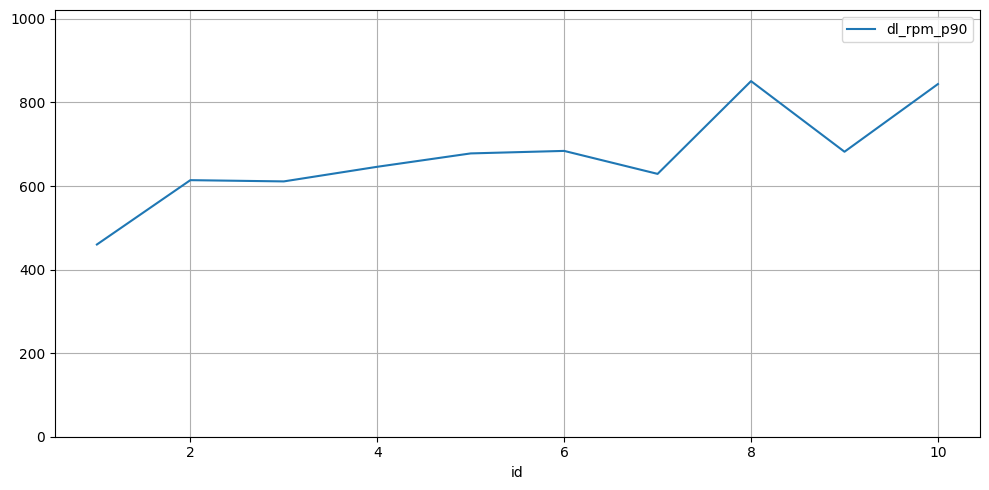

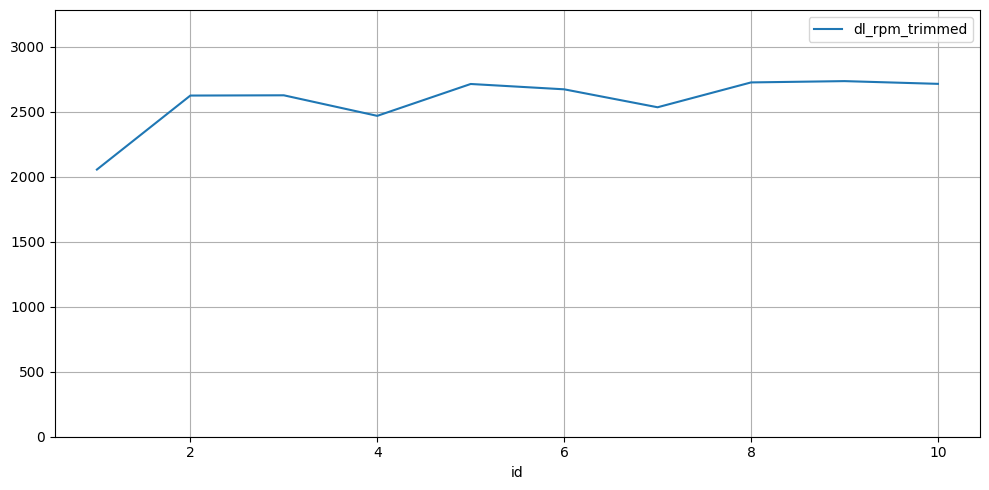

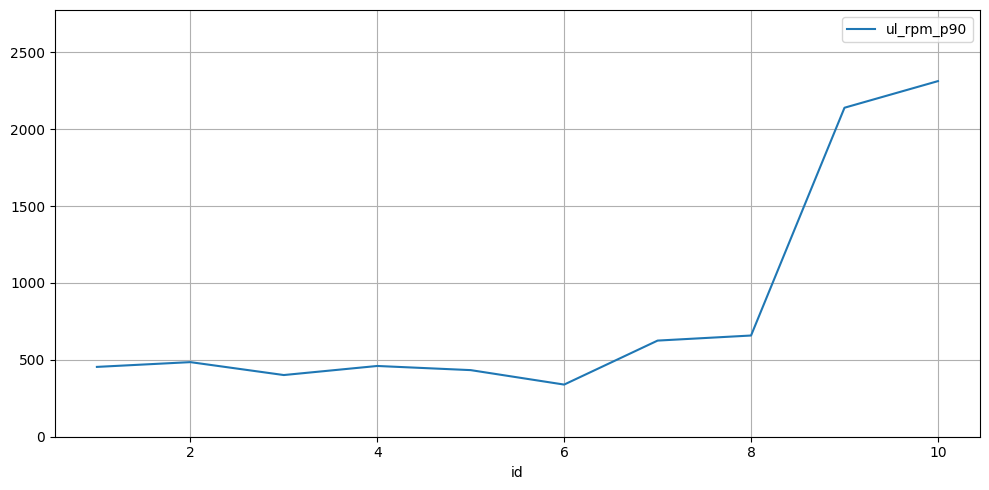

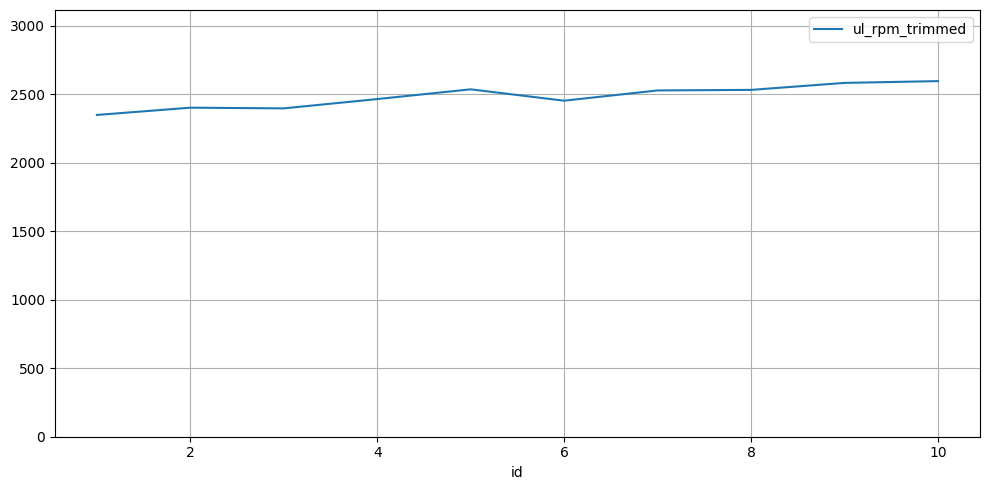

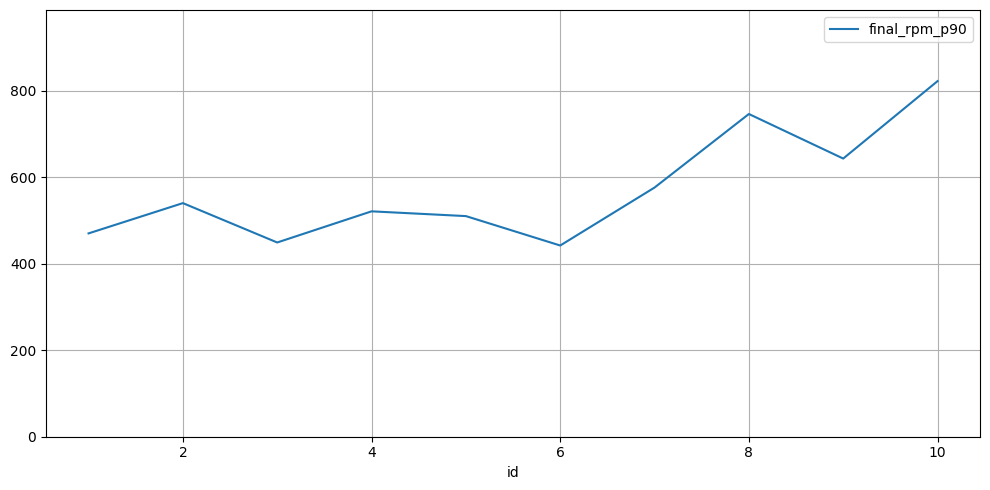

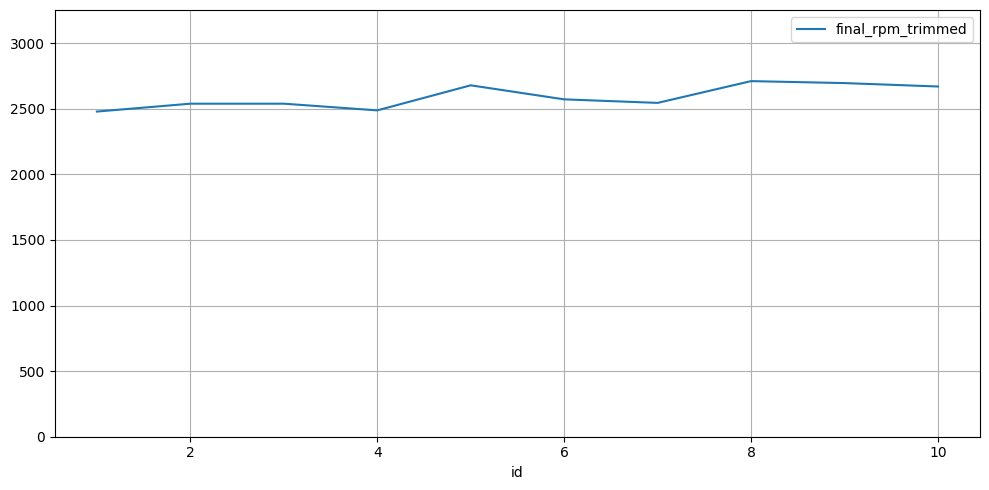

In [9]:
id_df = df.loc[df['exp_parameters'] == "FiberGlas id"]

for out in outputs_int:
    y_max = id_df[out].max()
    id_df.plot(x="id", y=out, figsize=(10, 5), ylim=(0, y_max * 1.2), grid=True)
    plt.tight_layout()

Note:
- RPM_P90 suddenly increases at 9 id

<h4>Stability</h4>

<Figure size 640x480 with 0 Axes>

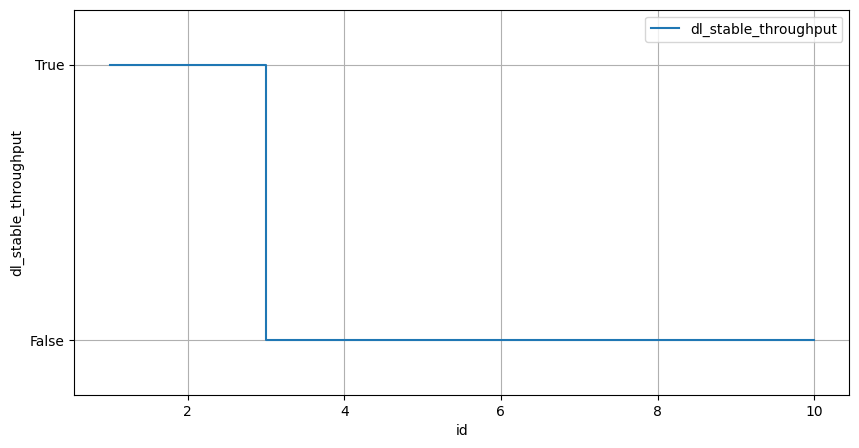

<Figure size 640x480 with 0 Axes>

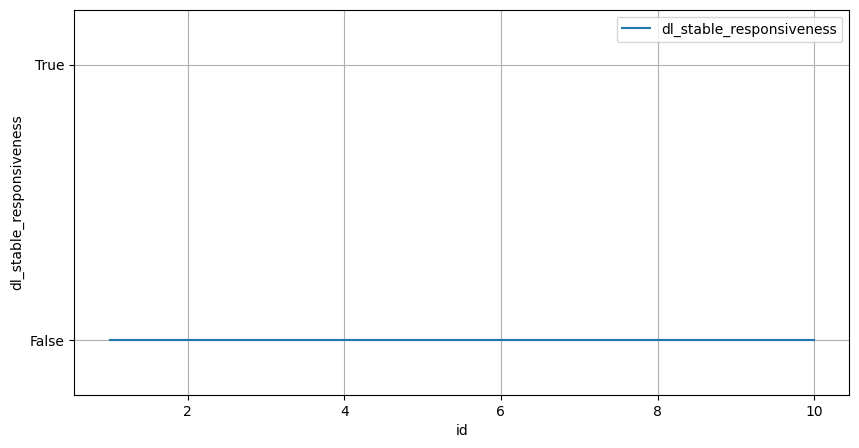

<Figure size 640x480 with 0 Axes>

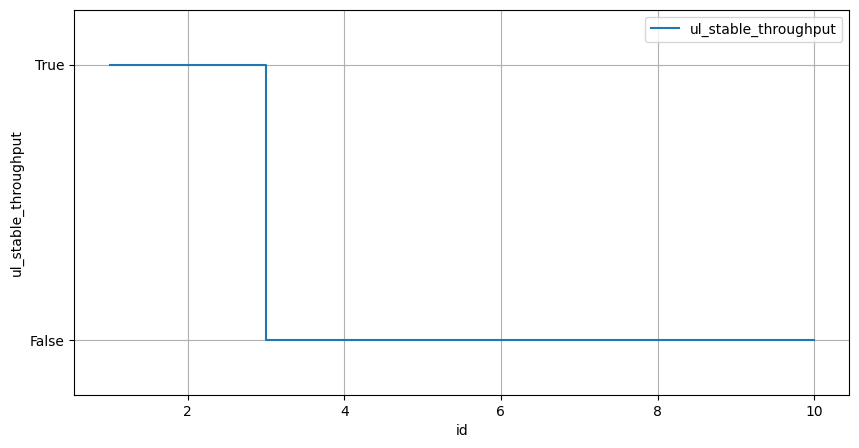

<Figure size 640x480 with 0 Axes>

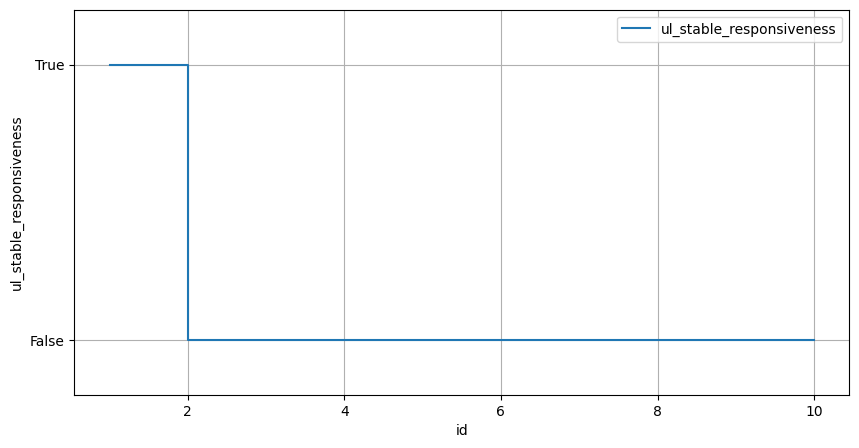

In [10]:
for out in outputs_bool:
    plt.figure()
    id_df.plot(x="id", y=out, figsize=(10, 5), grid=True, drawstyle='steps-post', xlabel="id", ylabel=out)

    plt.yticks([0,1], ['False', 'True'])
    plt.ylim(-0.2, 1.2)
    plt.show()

Note:
- id of 2 or lower is more likely to achieve stability.
- download responsiveness is difficult to stabilize

<h4>Moving Average Distance(mad)</h4>
default 4

<h4>RPM</h4>

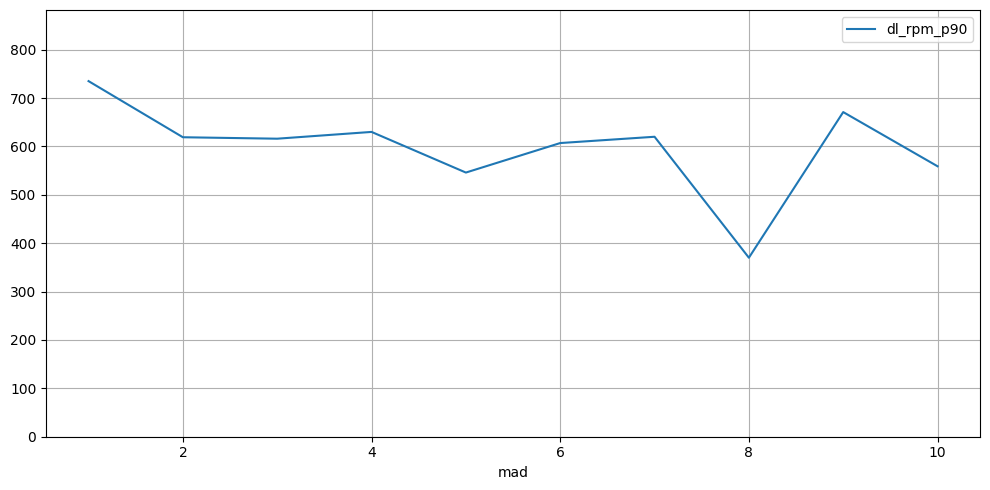

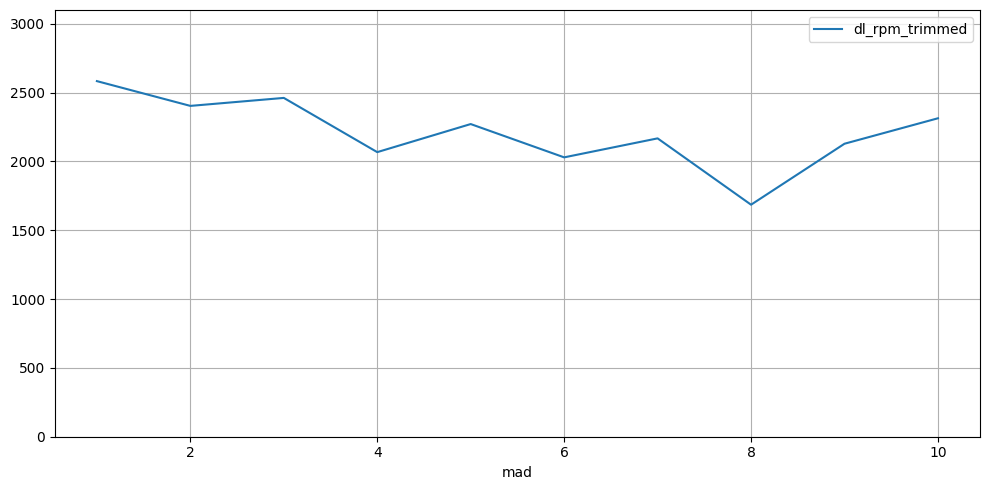

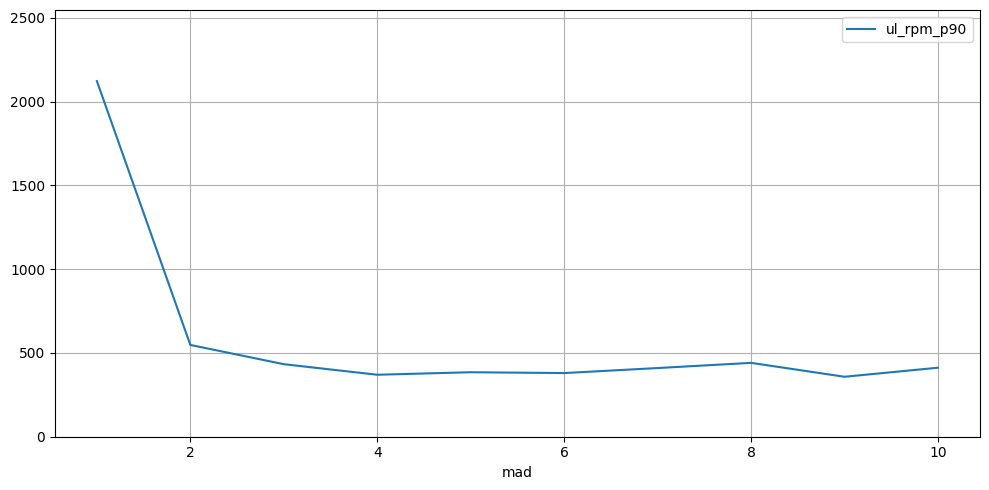

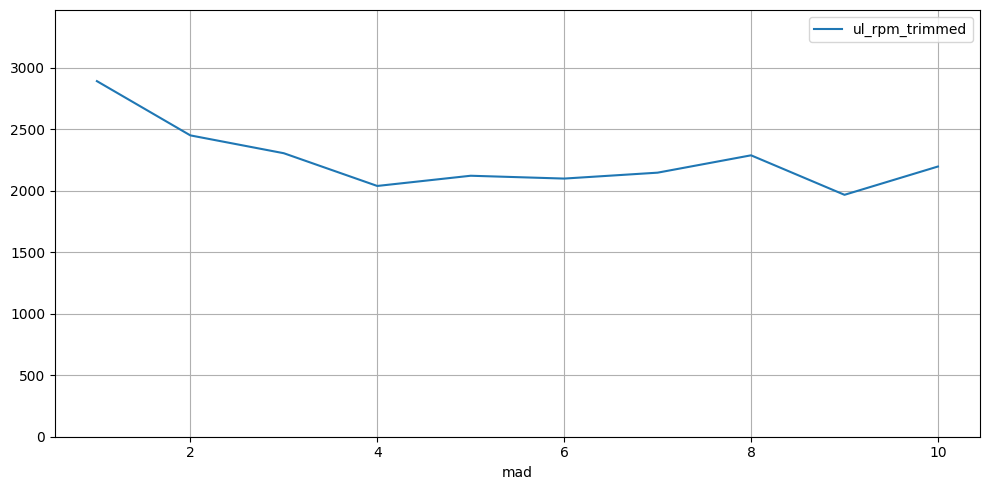

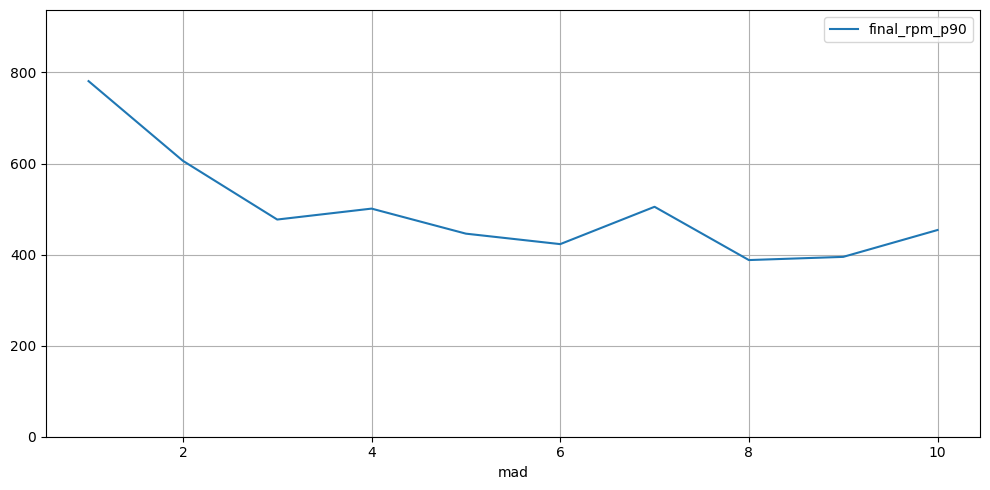

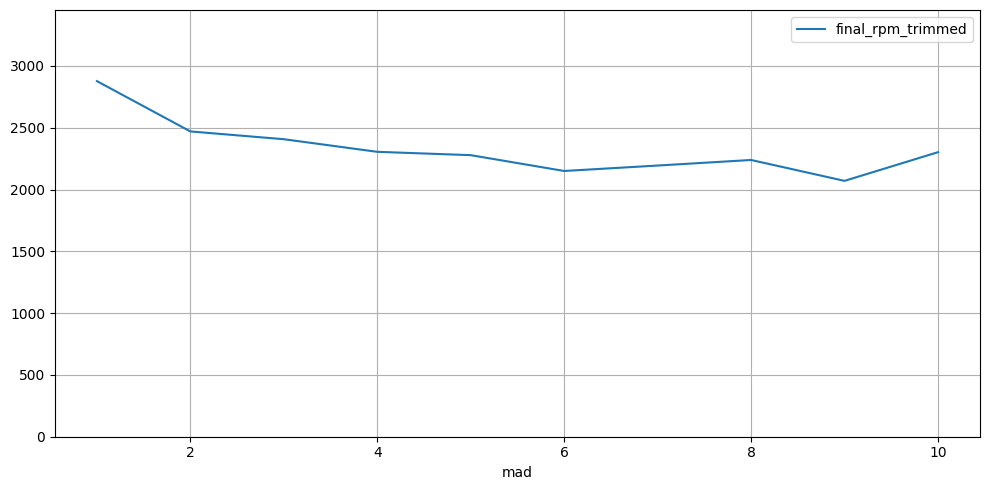

In [11]:
mad_df = df.loc[df['exp_parameters'] == "FiberGlas mad"]

for out in outputs_int:
    y_max = mad_df[out].max()
    mad_df.plot(x="mad", y=out, figsize=(10, 5), ylim=(0, y_max * 1.2), grid=True)
    plt.tight_layout()

Note:
- at mad=8 I had to remeasure
- mad of 3 or lower tends to increase (falsely overestimate) RPM (allegedly)

<h4>Stability</h4>

<Figure size 640x480 with 0 Axes>

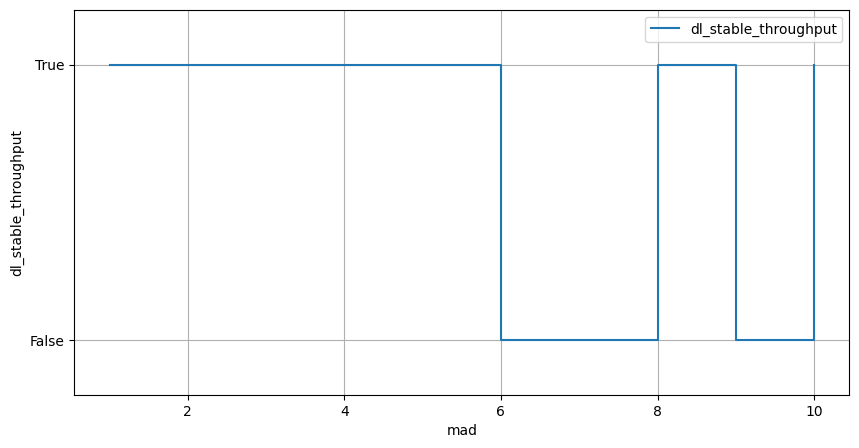

<Figure size 640x480 with 0 Axes>

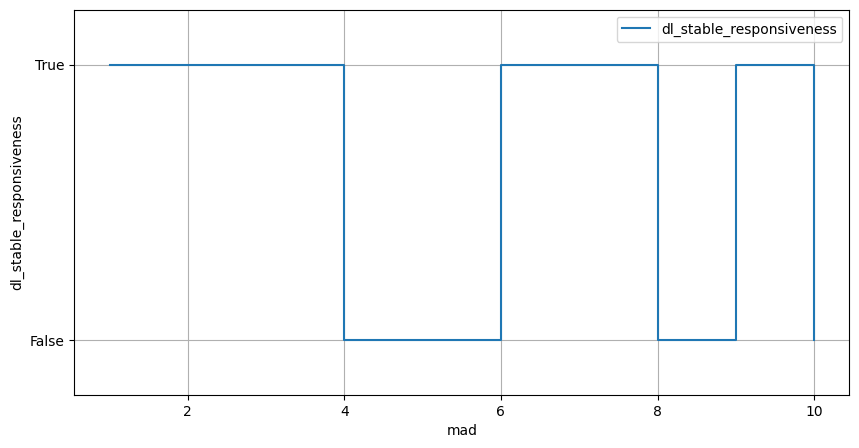

<Figure size 640x480 with 0 Axes>

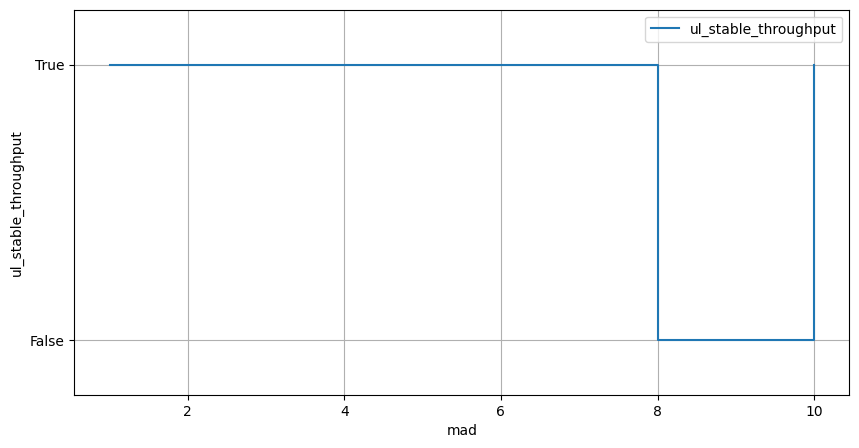

<Figure size 640x480 with 0 Axes>

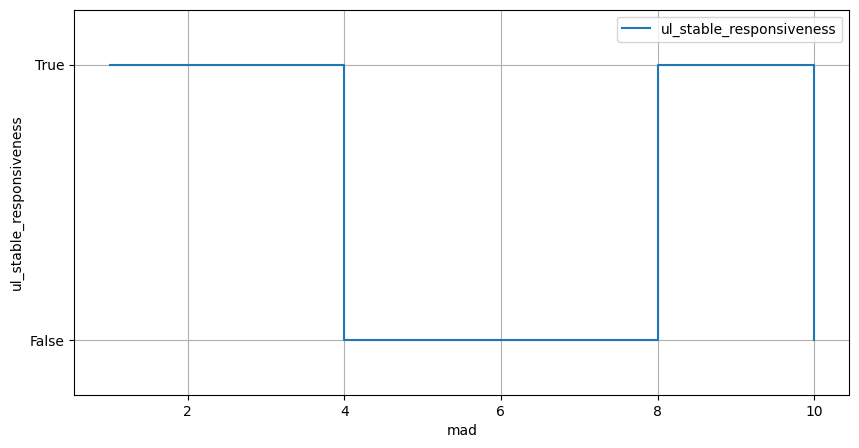

In [12]:
for out in outputs_bool:
    plt.figure()
    mad_df.plot(x="mad", y=out, figsize=(10, 5), grid=True, drawstyle='steps-post', xlabel="mad", ylabel=out)

    plt.yticks([0,1], ['False', 'True'])
    plt.ylim(-0.2, 1.2)
    plt.show()

Note:
- mad of 4 or lower tends to reach stability

<h4>Maximum Number of Parallel connections(mnp)</h4>
default 16

<h4>RPM</h4>

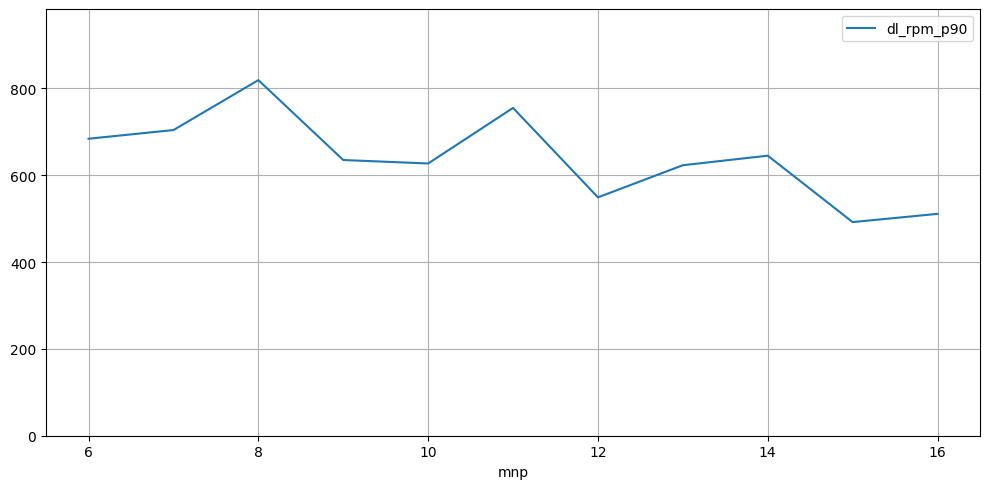

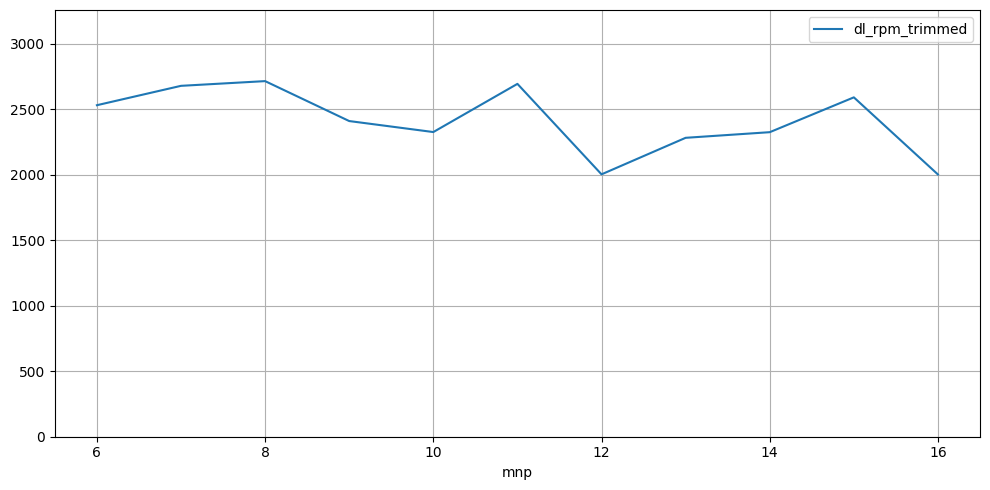

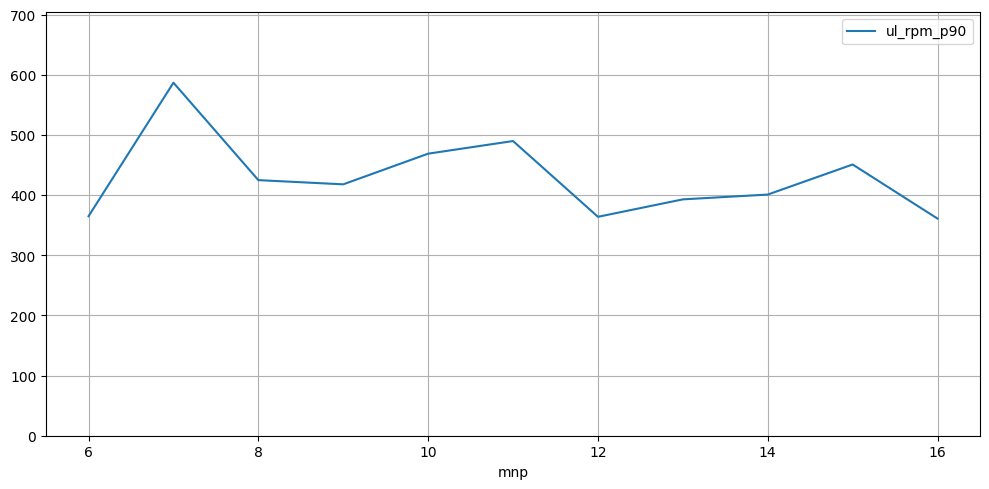

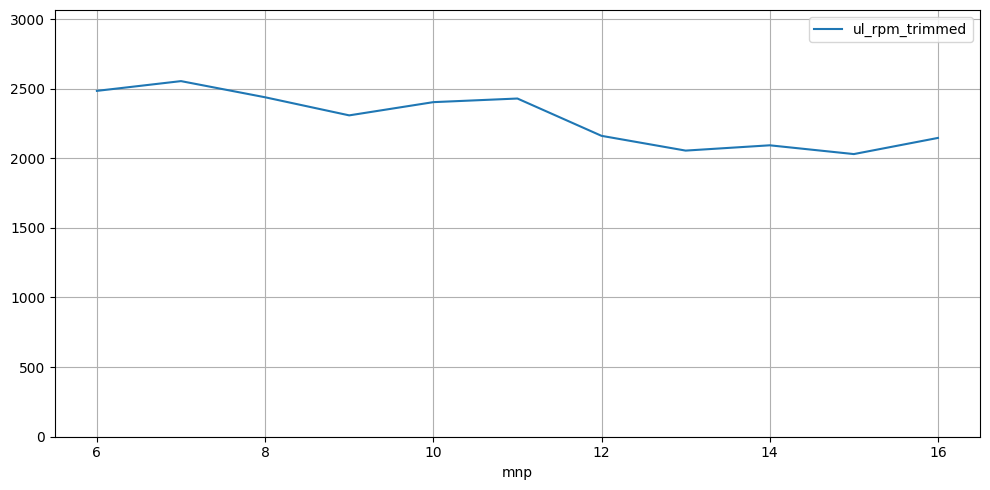

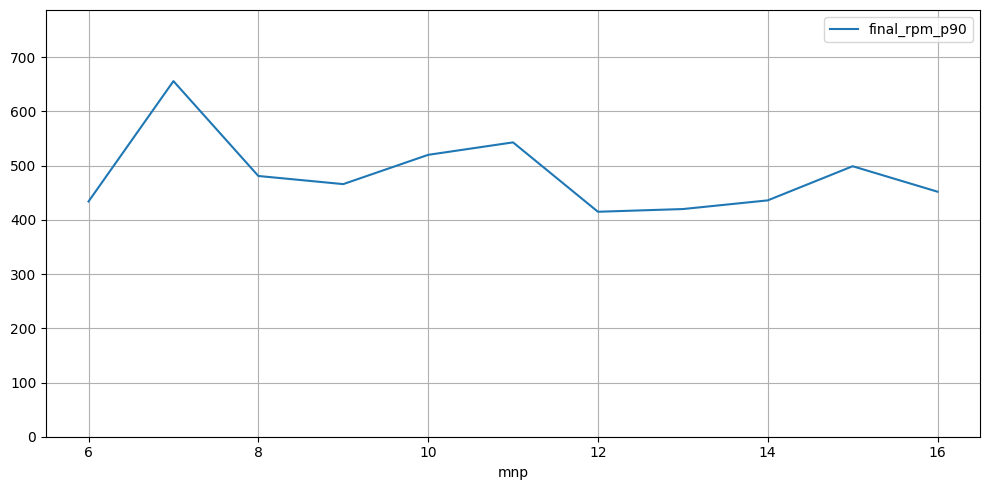

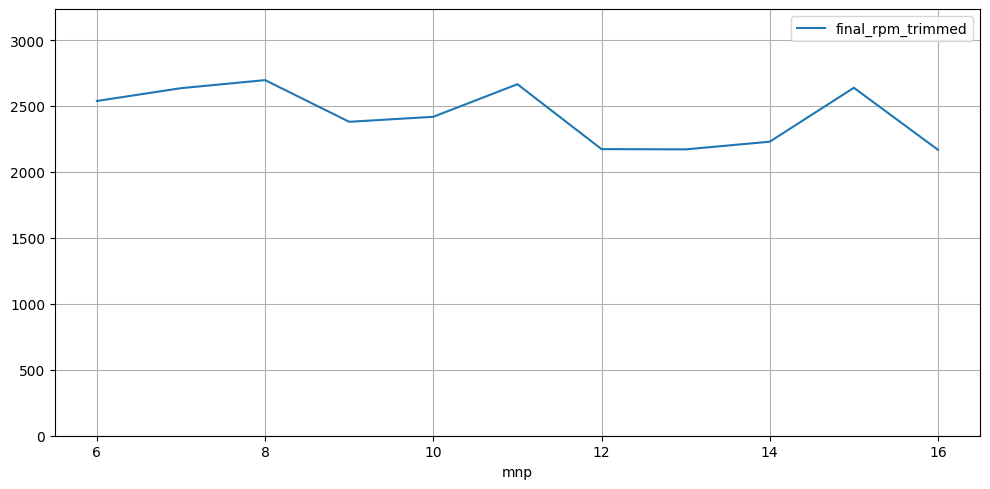

In [13]:
mnp_df = df.loc[df['exp_parameters'] == "FiberGlas mnp"]

for out in outputs_int:
    y_max = mnp_df[out].max()
    mnp_df.plot(x="mnp", y=out, figsize=(10, 5), ylim=(0, y_max * 1.2), grid=True)
    plt.tight_layout()

Note:
- decreases with higher value
- it seems that the value could be even higher

<h4>Stability</h4>

<Figure size 640x480 with 0 Axes>

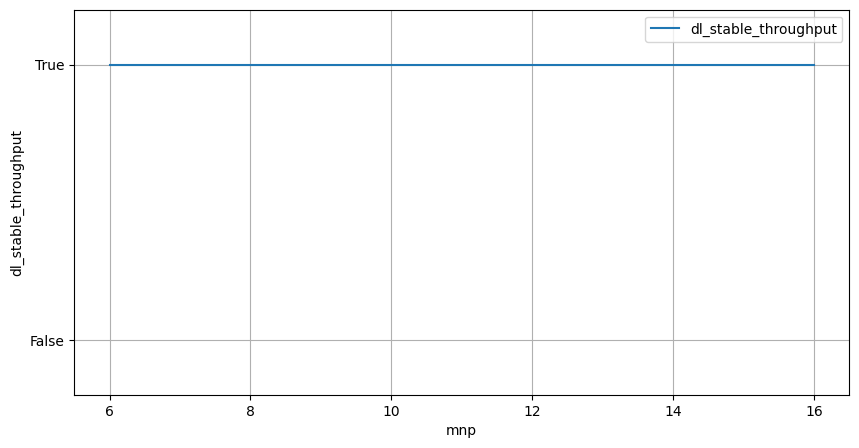

<Figure size 640x480 with 0 Axes>

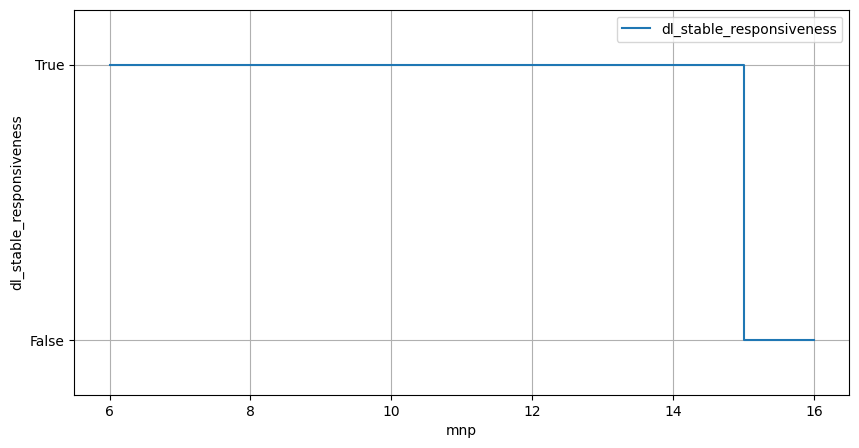

<Figure size 640x480 with 0 Axes>

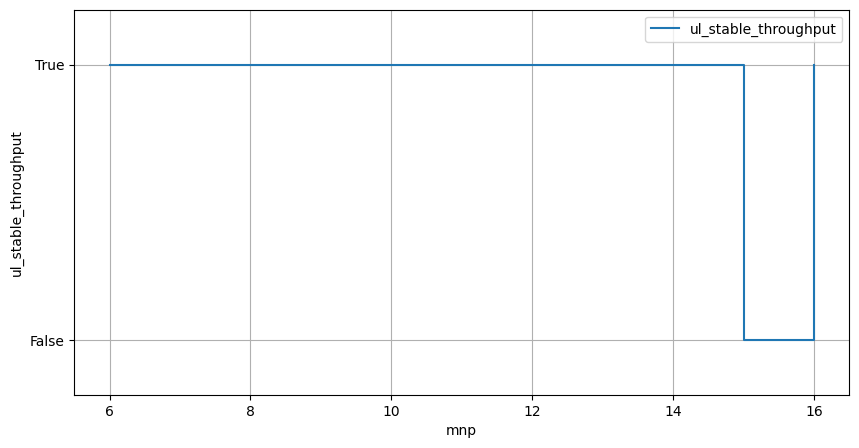

<Figure size 640x480 with 0 Axes>

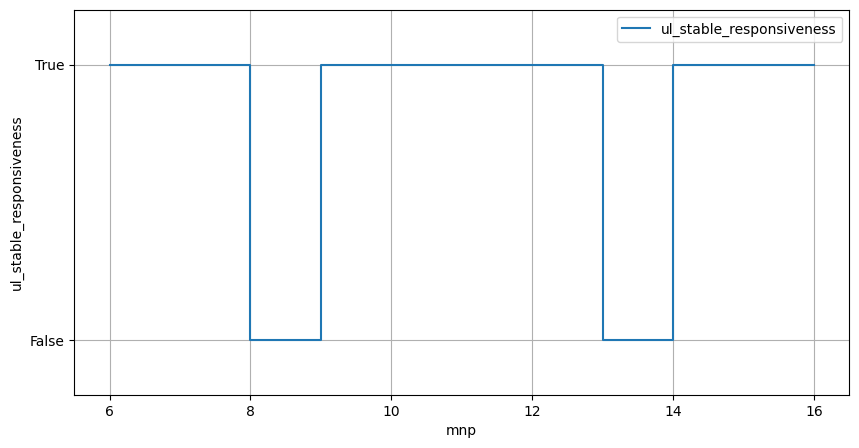

In [14]:
for out in outputs_bool:
    plt.figure()
    mnp_df.plot(x="mnp", y=out, figsize=(10, 5), grid=True, drawstyle='steps-post', xlabel="mnp", ylabel=out)

    plt.yticks([0,1], ['False', 'True'])
    plt.ylim(-0.2, 1.2)
    plt.show()

Note:
- if the mnp converges towards the default value, the stability tanks

<h4>Maximum number of Probes(mps)</h4>
default 100

<h4>RPM</h4>

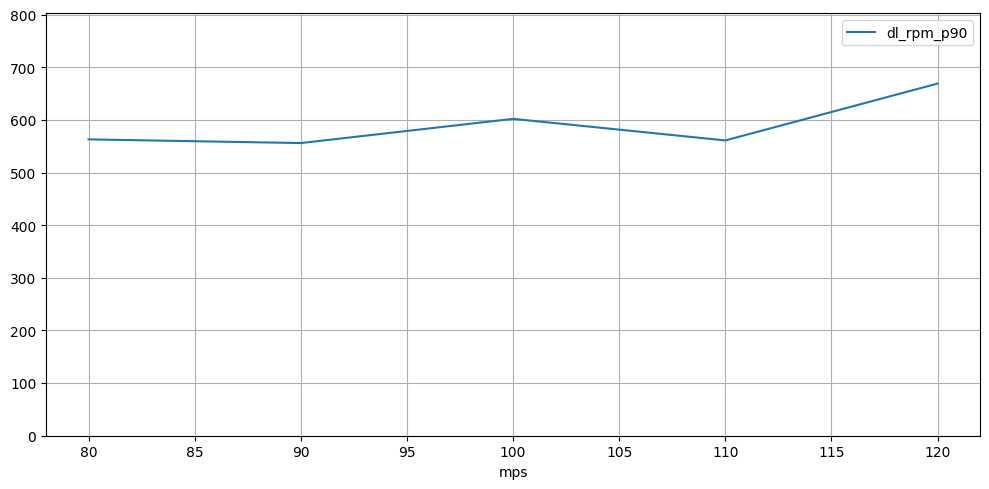

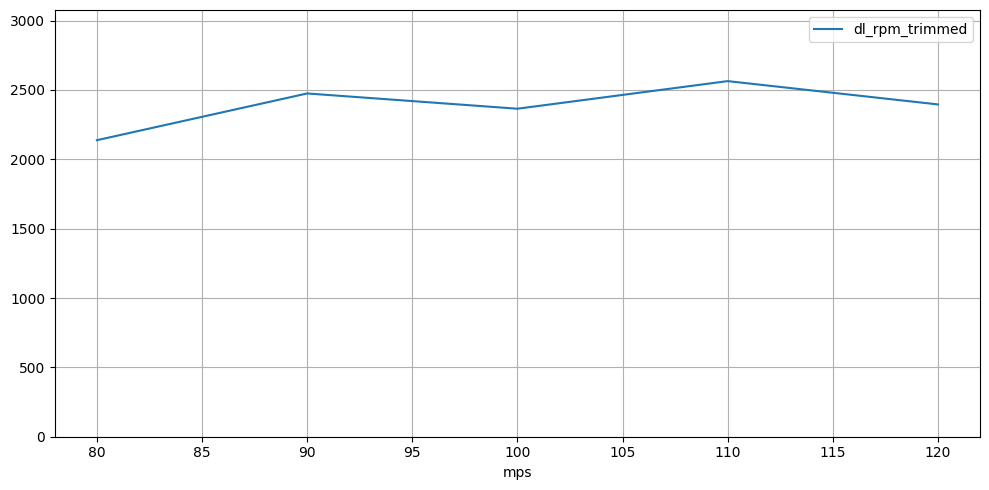

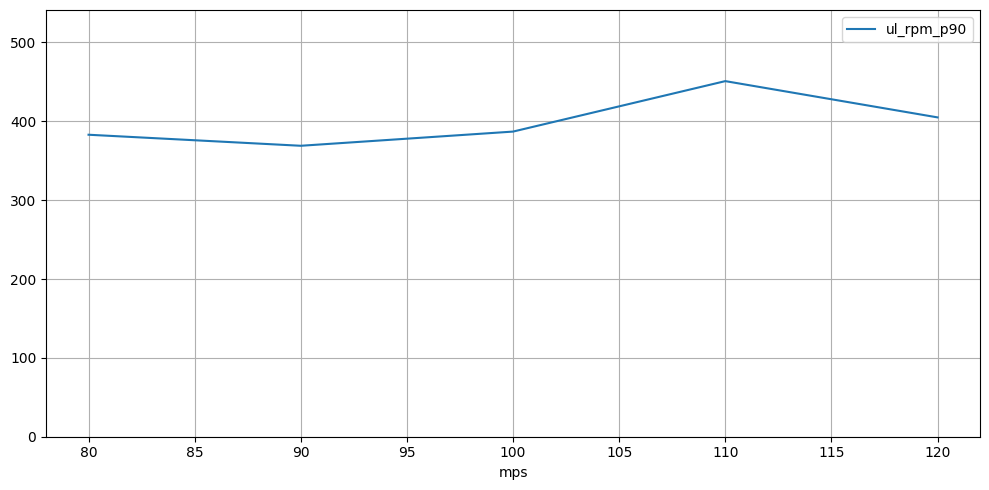

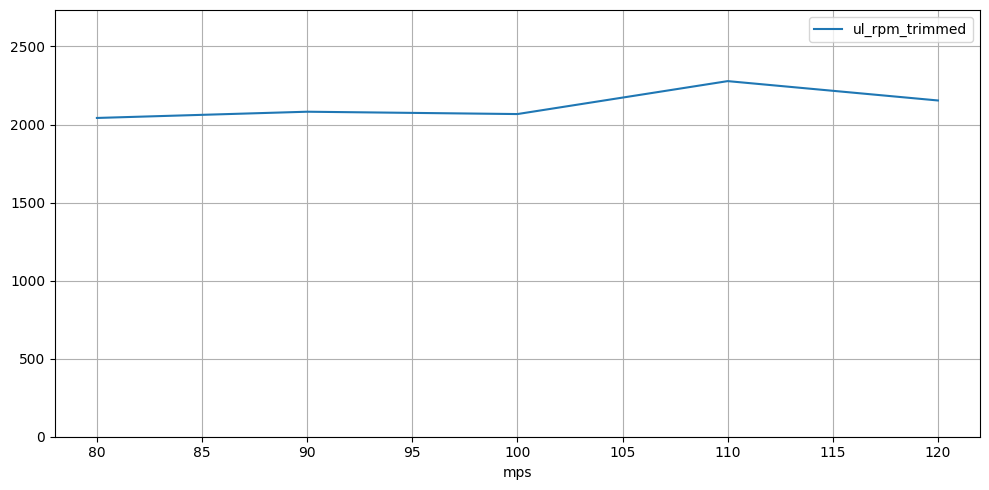

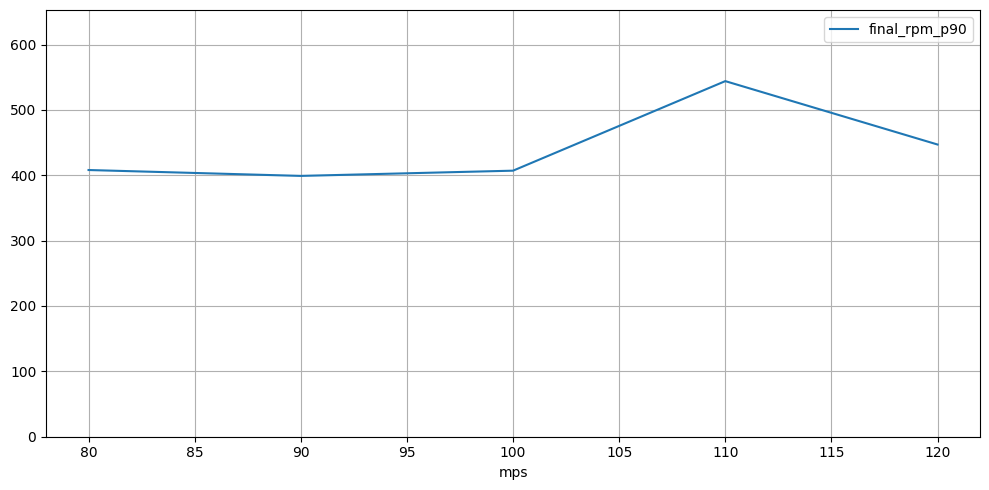

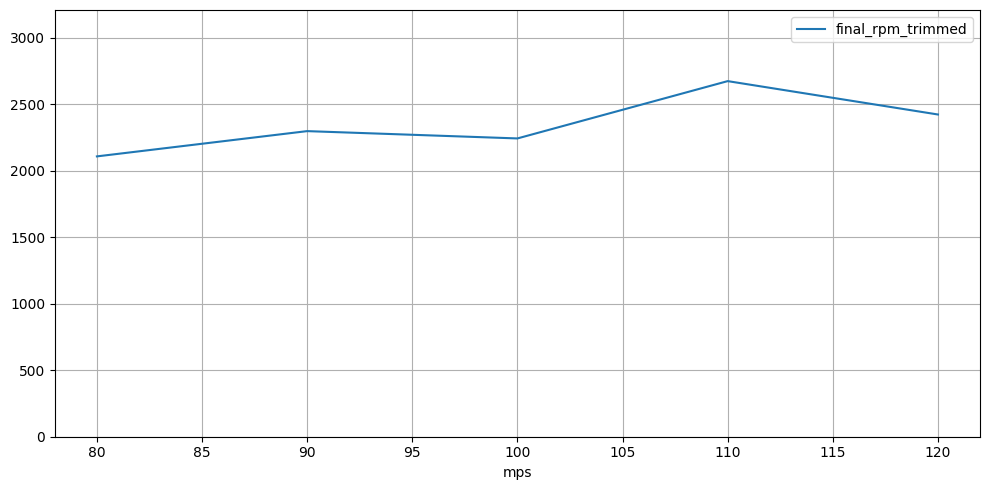

In [15]:
mps_df = df.loc[df['exp_parameters'] == "FiberGlas mps"]

for out in outputs_int:
    y_max = mps_df[out].max()
    mps_df.plot(x="mps", y=out, figsize=(10, 5), ylim=(0, y_max * 1.2), grid=True)
    plt.tight_layout()

Note:
- had to measure again for mps=120

<h4>Stability</h4>

<Figure size 640x480 with 0 Axes>

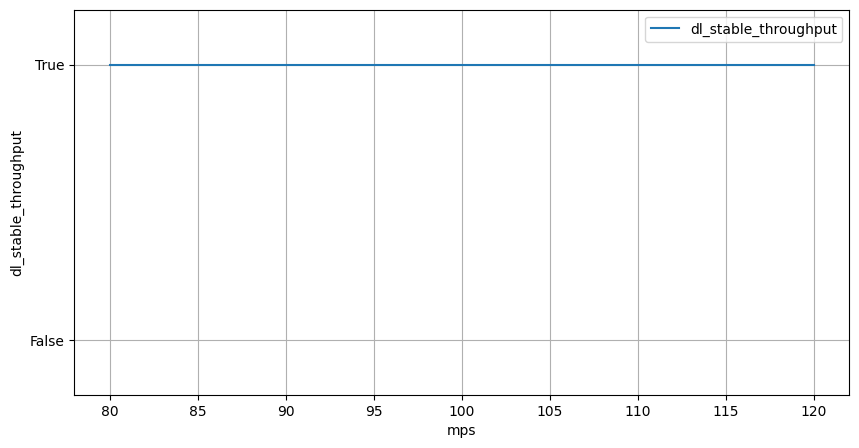

<Figure size 640x480 with 0 Axes>

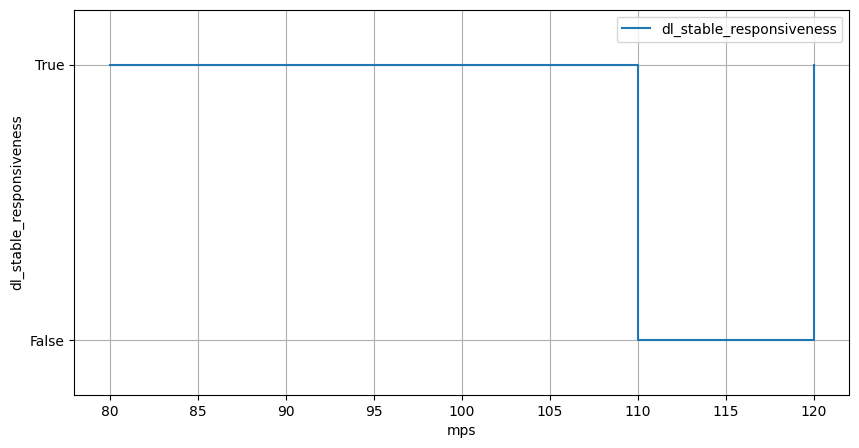

<Figure size 640x480 with 0 Axes>

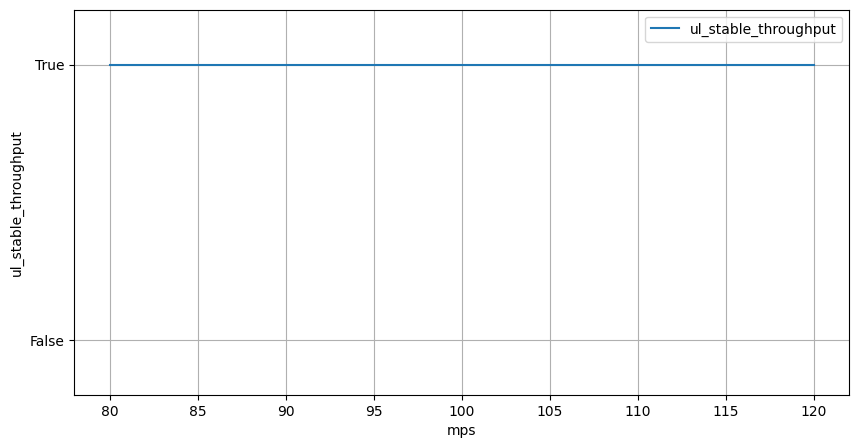

<Figure size 640x480 with 0 Axes>

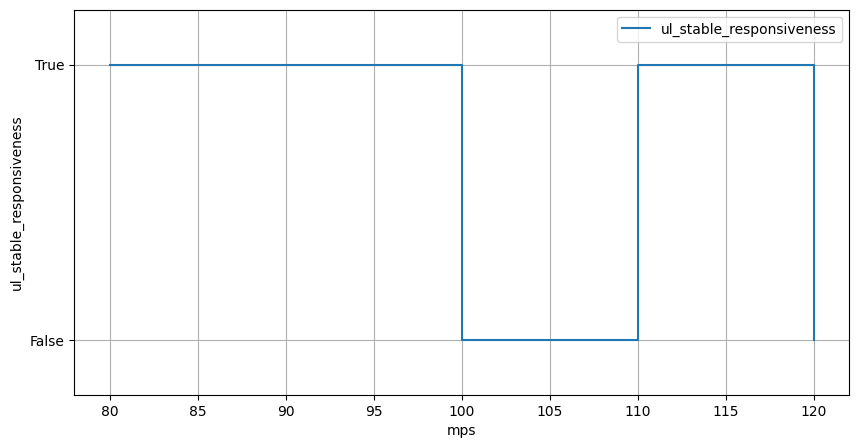

In [16]:
for out in outputs_bool:
    plt.figure()
    mps_df.plot(x="mps", y=out, figsize=(10, 5), grid=True, drawstyle='steps-post', xlabel="mps", ylabel=out)

    plt.yticks([0,1], ['False', 'True'])
    plt.ylim(-0.2, 1.2)
    plt.show()

Note:
- lower value tends to show better stability

<h4>Percentile of results when calculating responsiveness(p)</h4>
default 90

<h4>RPM</h4>

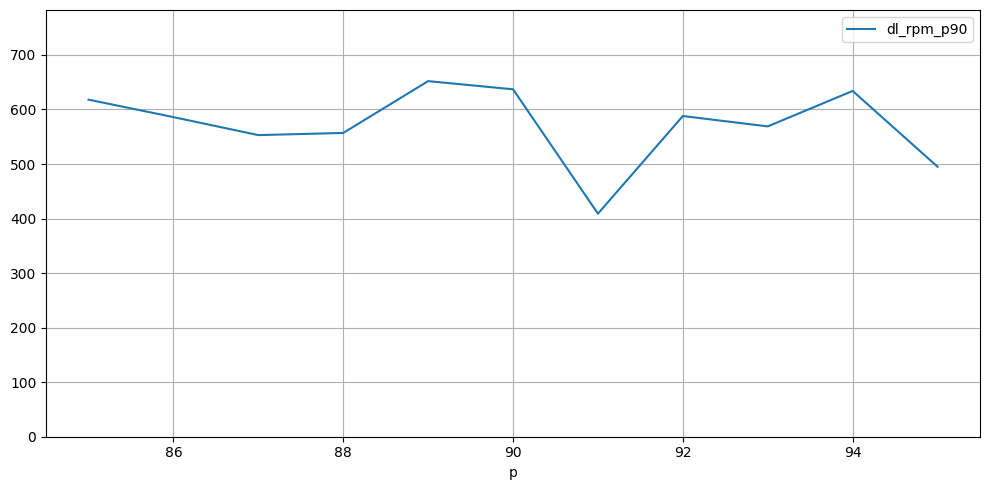

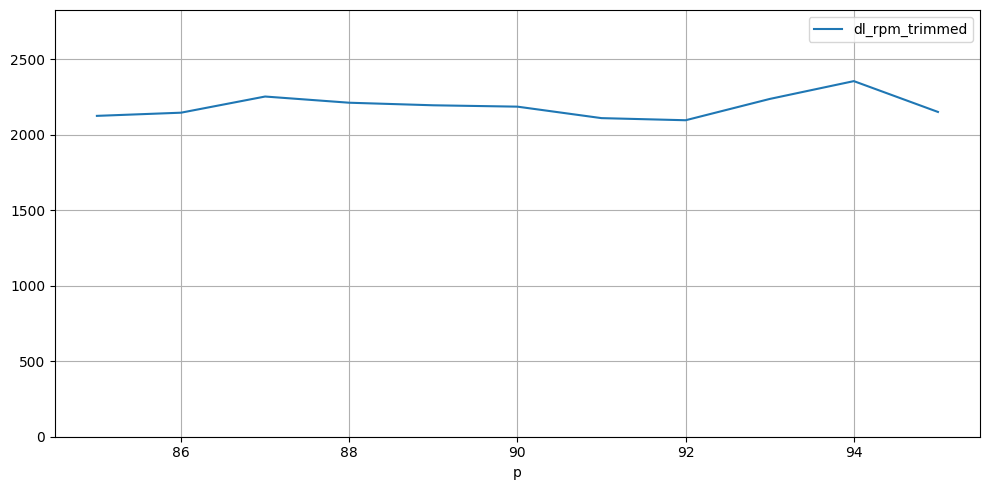

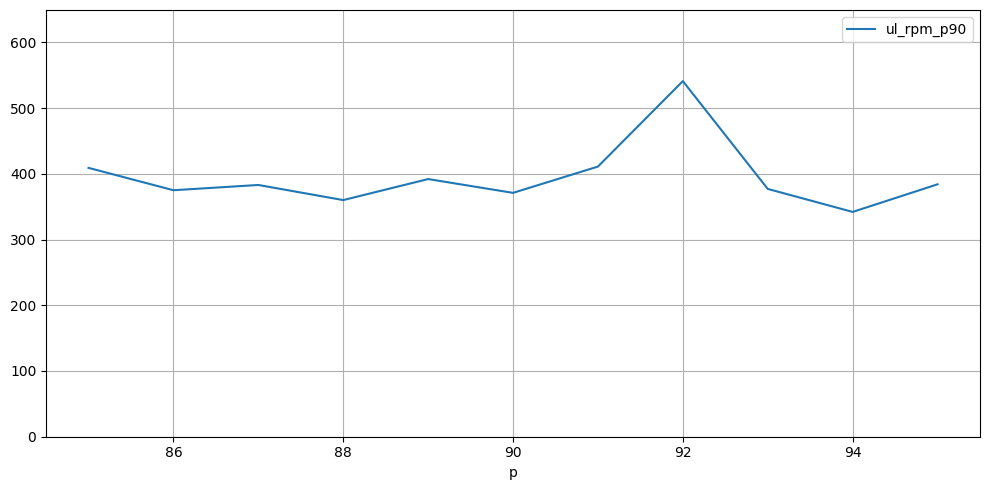

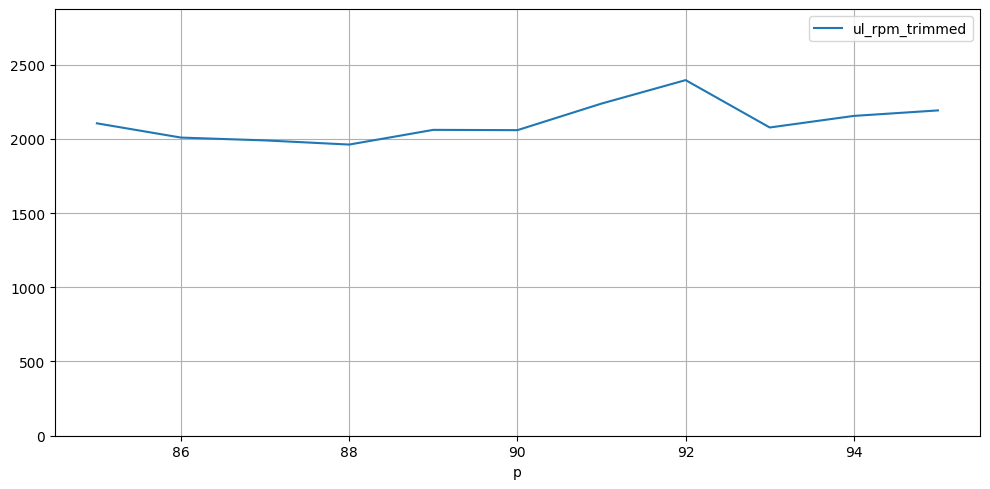

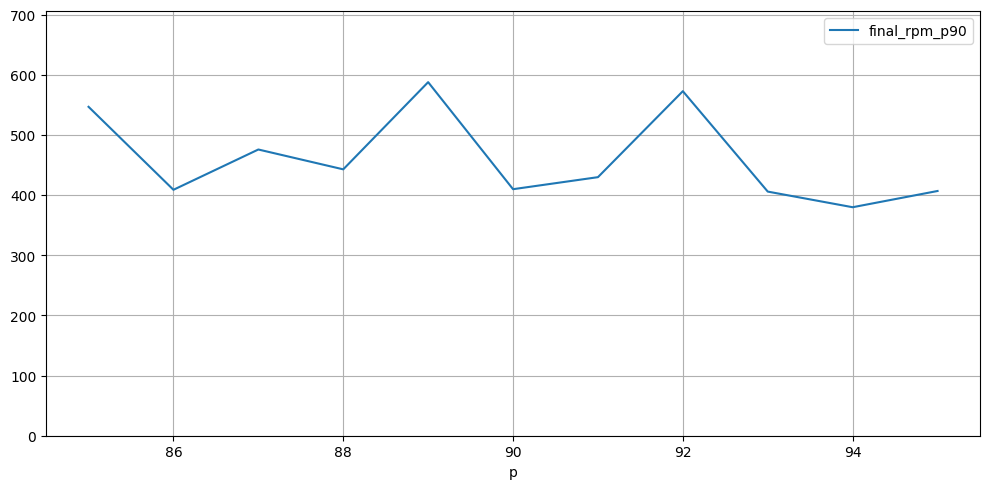

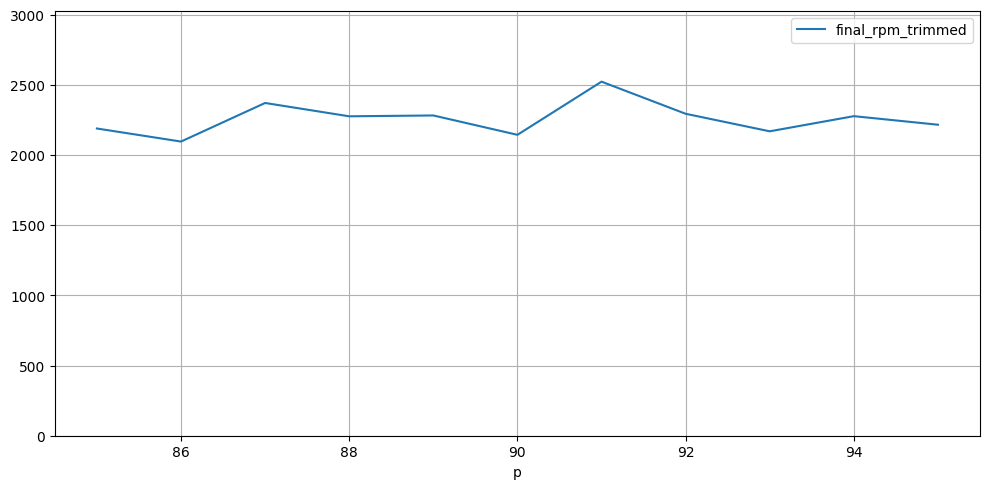

In [17]:
p_df = df.loc[df['exp_parameters'] == "FiberGlas p"]

for out in outputs_int:
    y_max = p_df[out].max()
    p_df.plot(x="p", y=out, figsize=(10, 5), ylim=(0, y_max * 1.2), grid=True)
    plt.tight_layout()

Note:
- could be more aggressive with the steps

<h4>Stability</h4>

<Figure size 640x480 with 0 Axes>

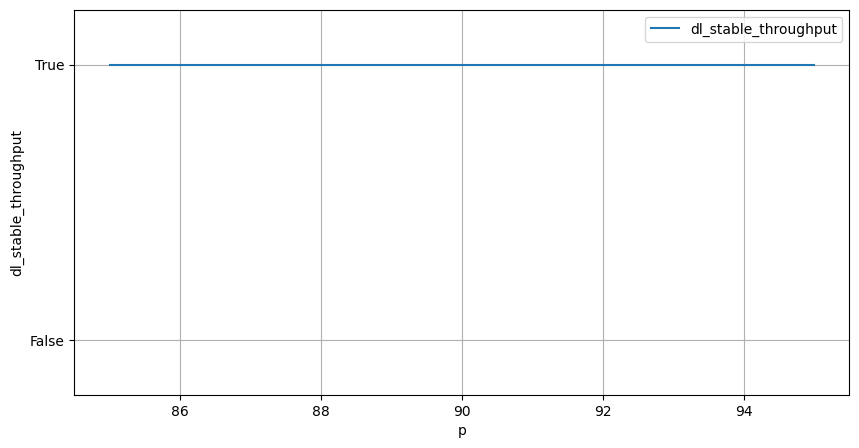

<Figure size 640x480 with 0 Axes>

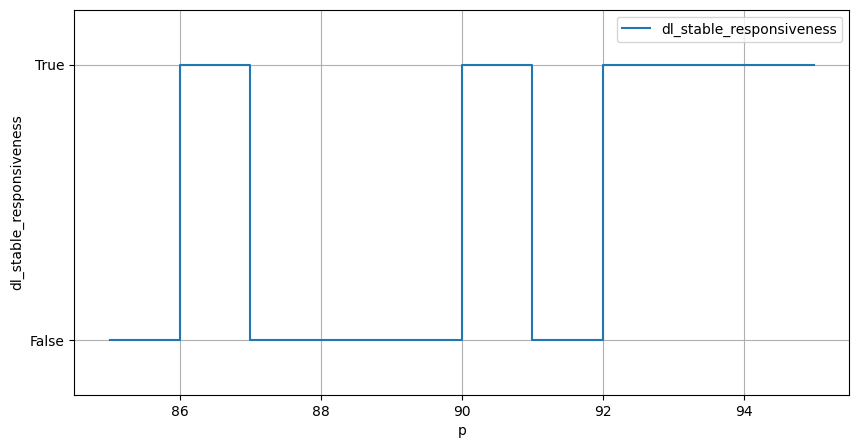

<Figure size 640x480 with 0 Axes>

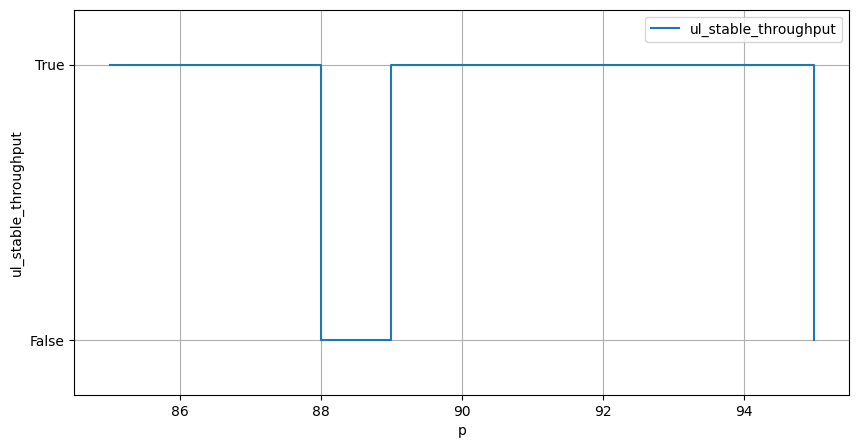

<Figure size 640x480 with 0 Axes>

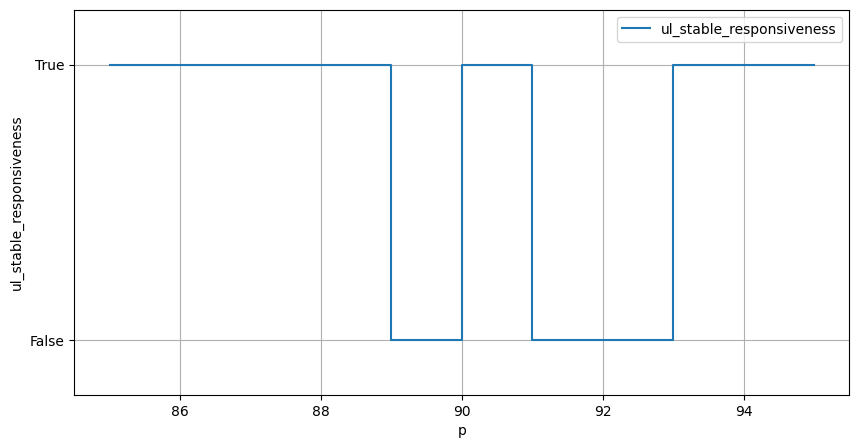

In [18]:
for out in outputs_bool:
    plt.figure()
    p_df.plot(x="p", y=out, figsize=(10, 5), grid=True, drawstyle='steps-post', xlabel="p", ylabel=out)

    plt.yticks([0,1], ['False', 'True'])
    plt.ylim(-0.2, 1.2)
    plt.show()

Note:
- it's hard to say, whether the stability is affected by this parameter

<h4>Prallel up and downlink test(parallel)</h4>

In [19]:
parallel_df = df.loc[df['exp_parameters'] == "FiberGlas parallel"]

print(parallel_df[outputs])

    dl_stable_throughput  dl_stable_responsiveness  dl_rpm_p90  \
47                     1                         0         182   

    dl_rpm_trimmed  ul_stable_throughput  ul_stable_responsiveness  \
47            1482                     1                         1   

    ul_rpm_p90  ul_rpm_trimmed  final_rpm_p90  final_rpm_trimmed  
47         278            1941            220               1668  


<h4>Percentage of network capacity that probes are allowed to take(ptc)</h4>
default 0.05

<h4>RPM</h4>

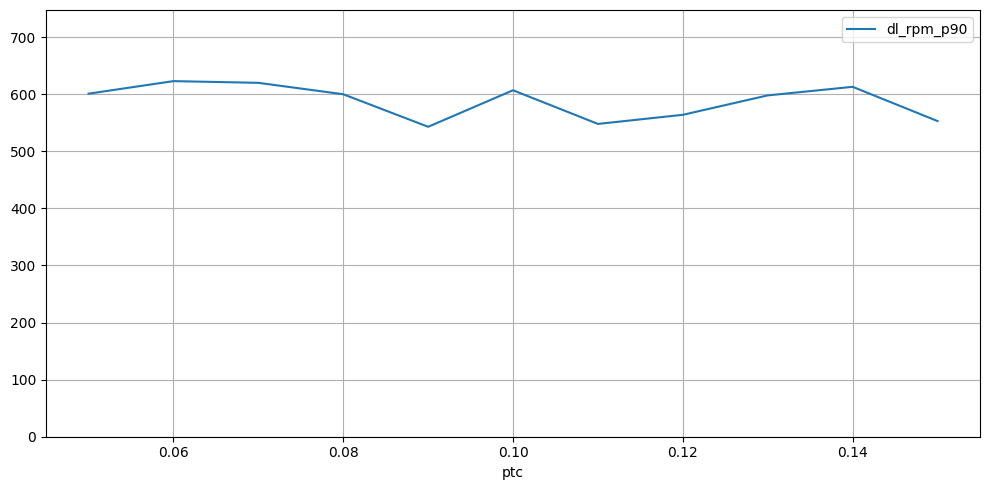

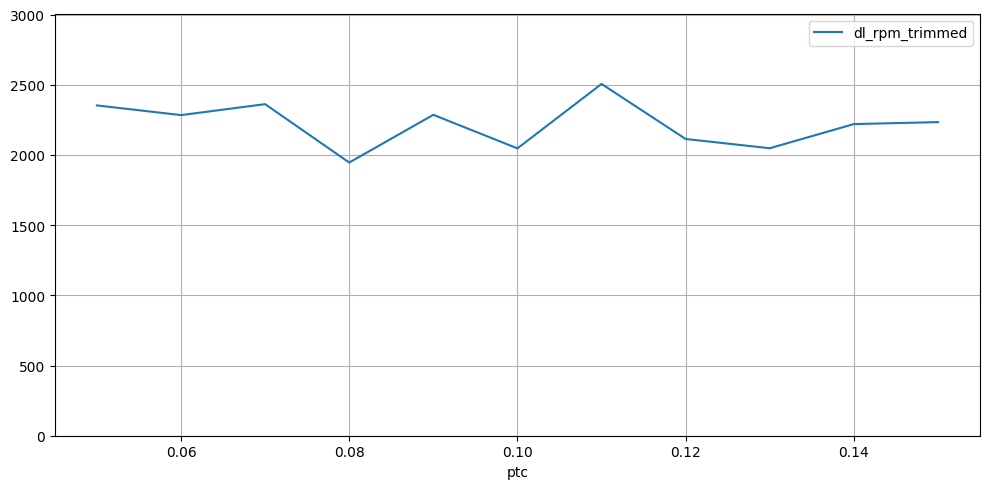

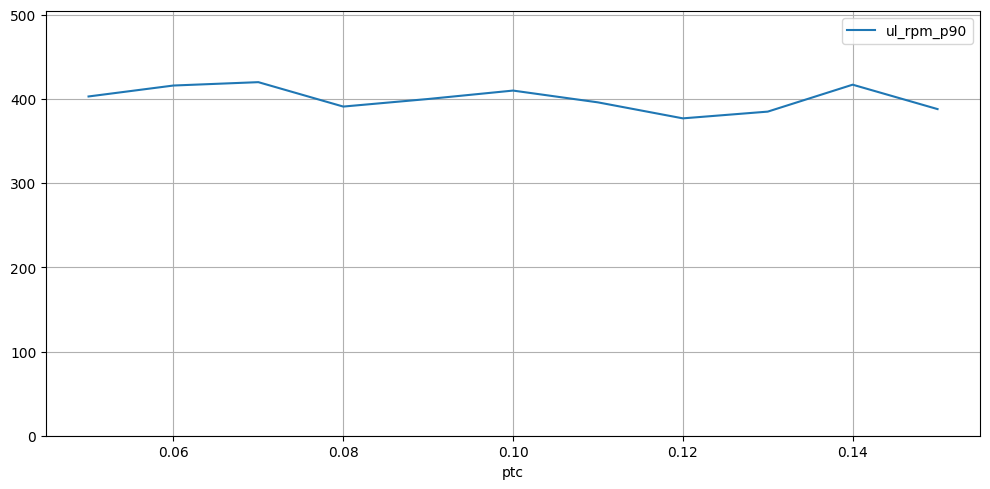

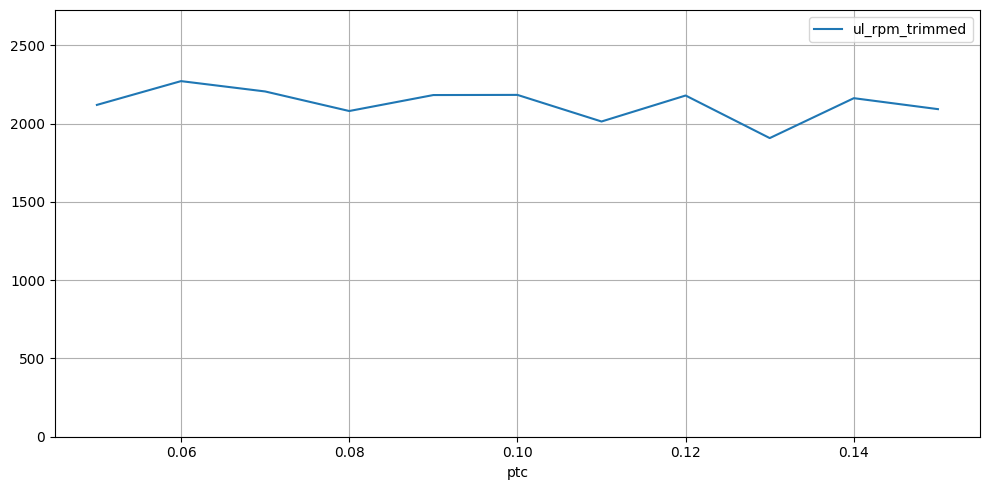

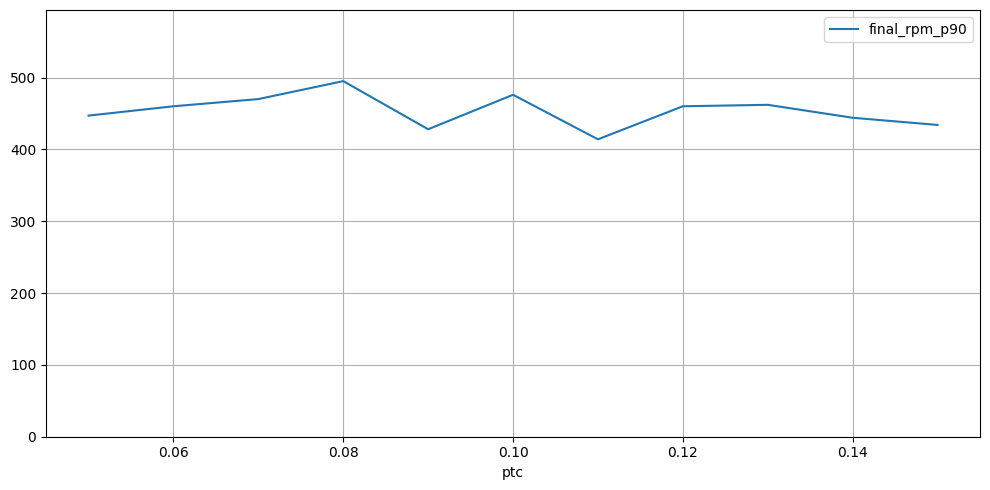

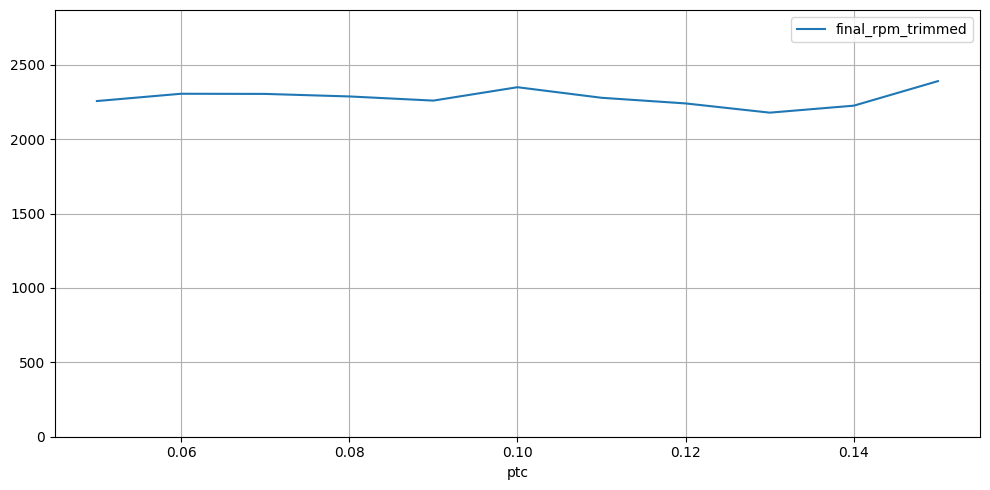

In [20]:
ptc_df = df.loc[df['exp_parameters'] == "FiberGlas ptc"]

for out in outputs_int:
    y_max = ptc_df[out].max()
    ptc_df.plot(x="ptc", y=out, figsize=(10, 5), ylim=(0, y_max * 1.2), grid=True)
    plt.tight_layout()

Note:
- RPM remains stable, so we could be more aggressive with the steps

<h4>Stability</h4>

<Figure size 640x480 with 0 Axes>

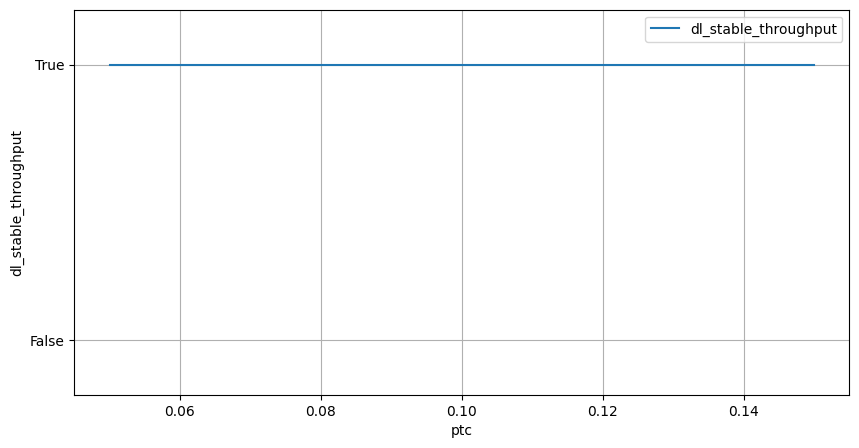

<Figure size 640x480 with 0 Axes>

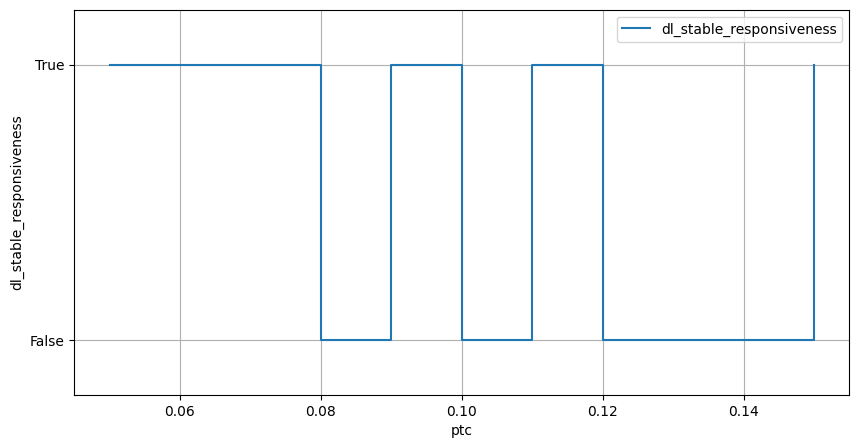

<Figure size 640x480 with 0 Axes>

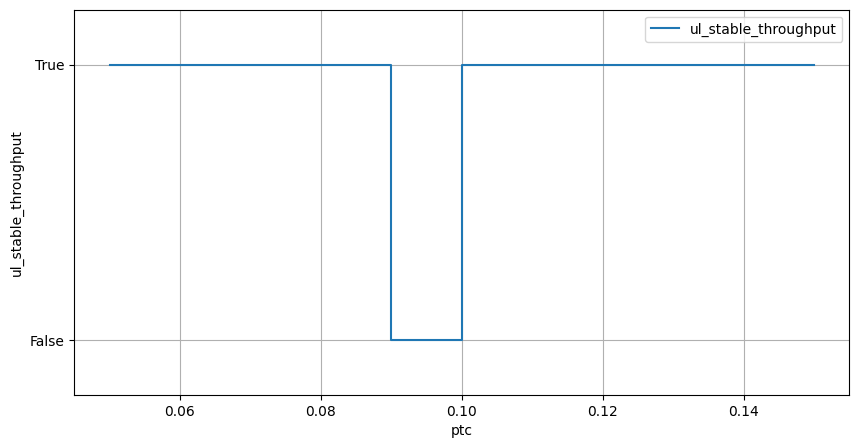

<Figure size 640x480 with 0 Axes>

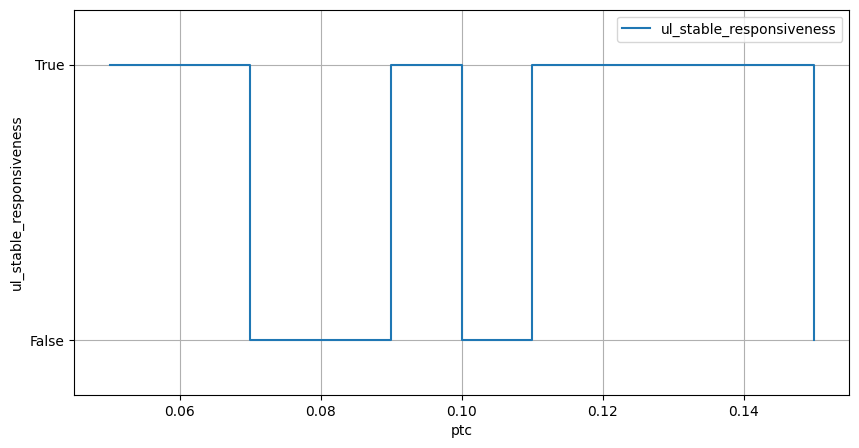

In [21]:
for out in outputs_bool:
    plt.figure()
    ptc_df.plot(x="ptc", y=out, figsize=(10, 5), grid=True, drawstyle='steps-post', xlabel="ptc", ylabel=out)

    plt.yticks([0,1], ['False', 'True'])
    plt.ylim(-0.2, 1.2)
    plt.show()

Doesnt seem to affect the stability, could be more aggressive

<h4>Standard Deviation Tolerance(sdt)</h4>
default 5

<h4>RPM</h4>

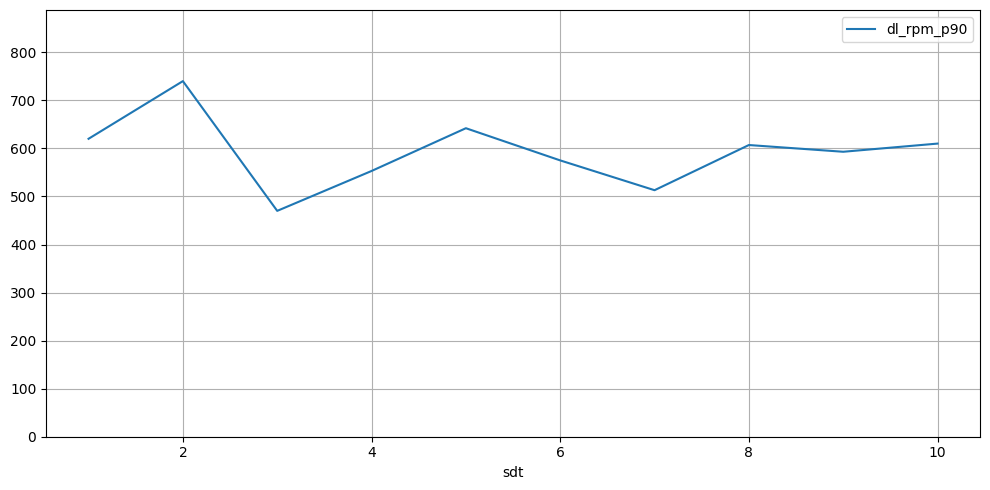

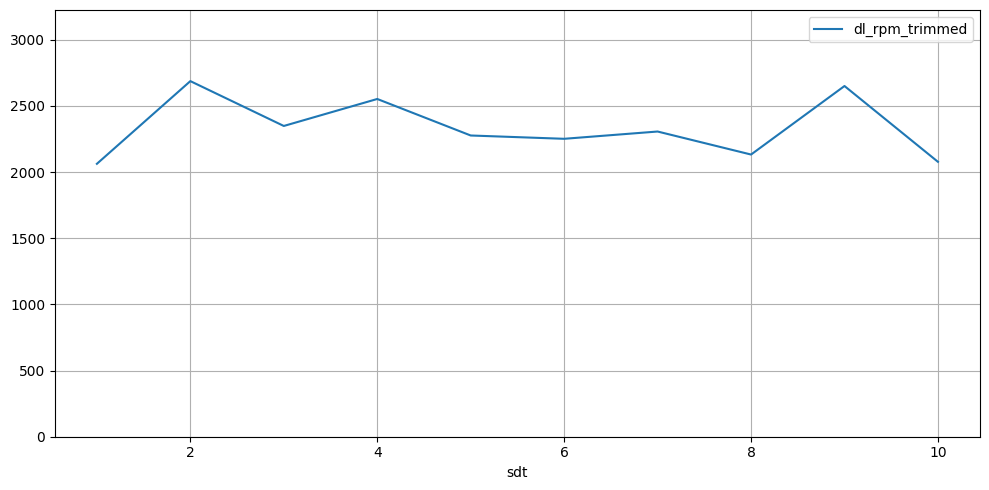

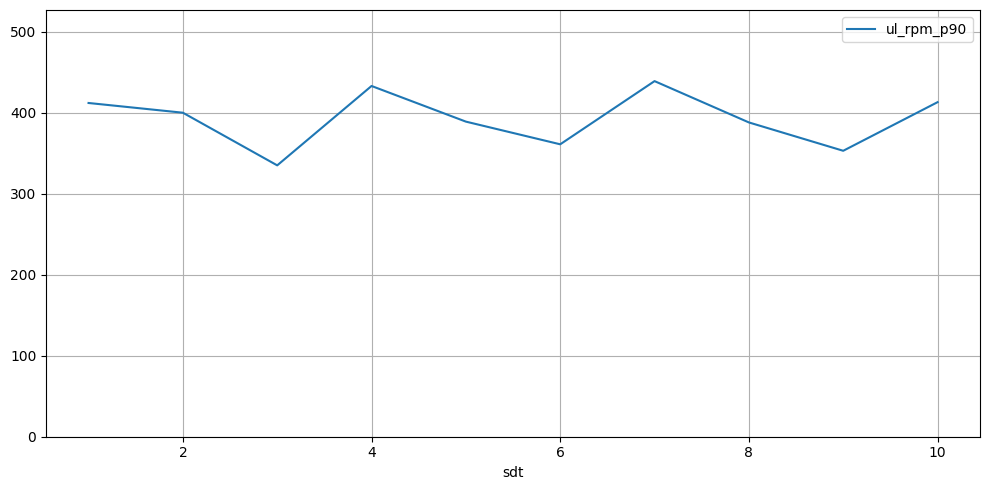

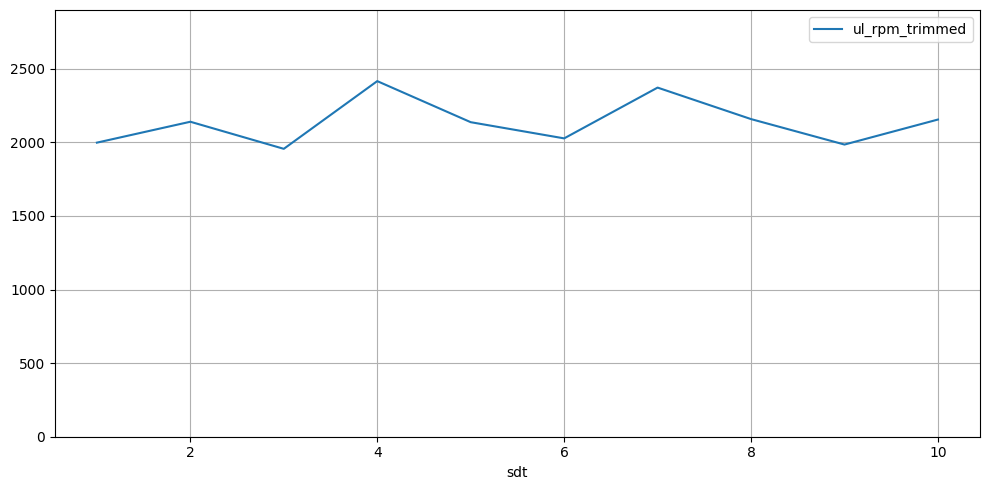

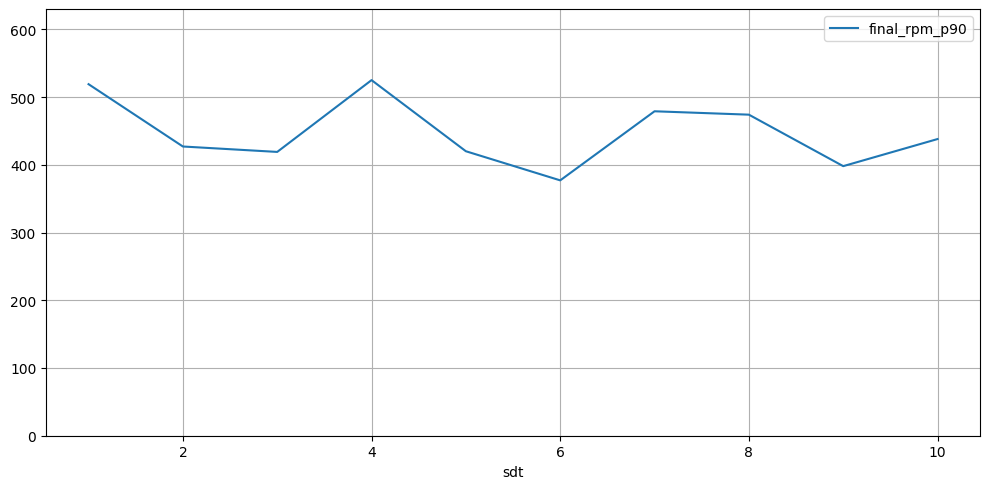

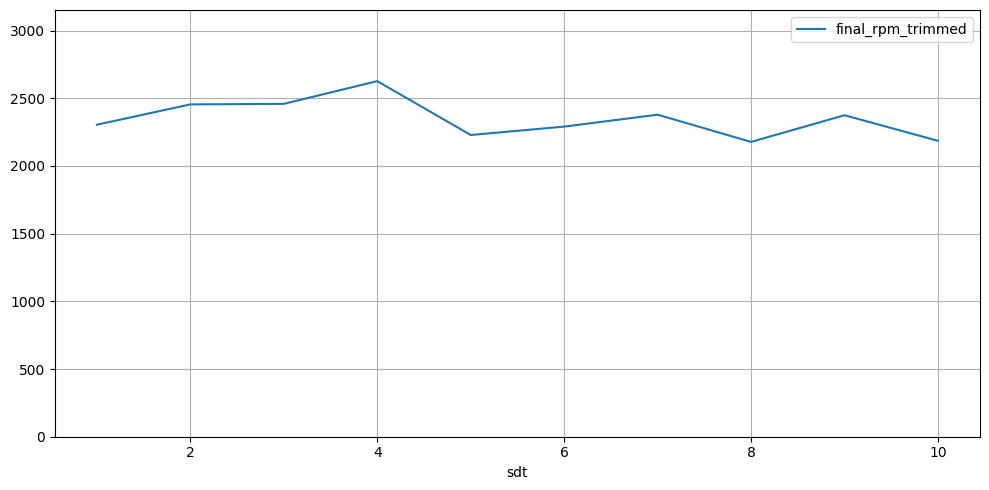

In [22]:
sdt_df = df.loc[df['exp_parameters'] == "FiberGlas sdt"]

for out in outputs_int:
    y_max = sdt_df[out].max()
    sdt_df.plot(x="sdt", y=out, figsize=(10, 5), ylim=(0, y_max * 1.2), grid=True)
    plt.tight_layout()

Does not seem to affect RPM that much?
Maybe some instability with lower sdt?

<h4>Stability</h4>

<Figure size 640x480 with 0 Axes>

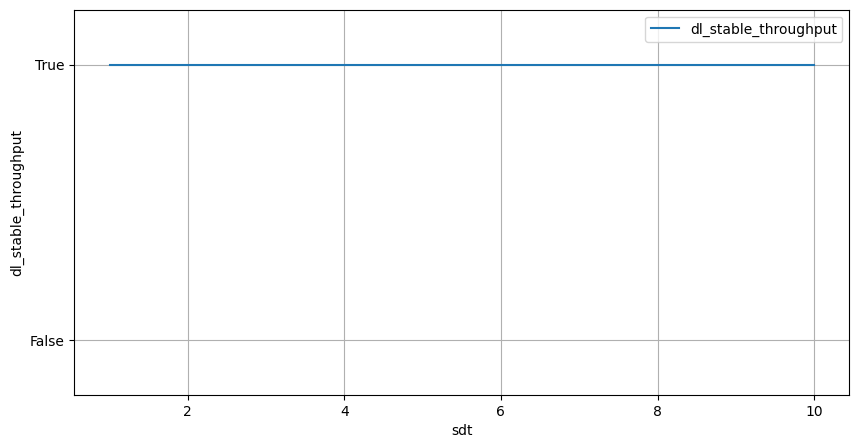

<Figure size 640x480 with 0 Axes>

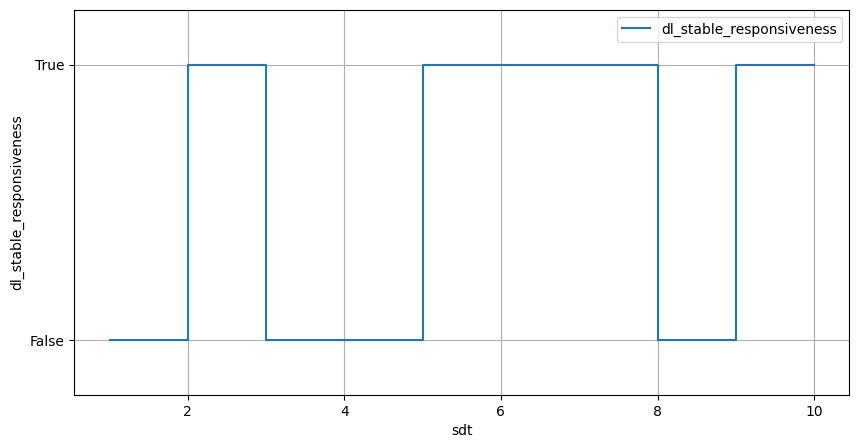

<Figure size 640x480 with 0 Axes>

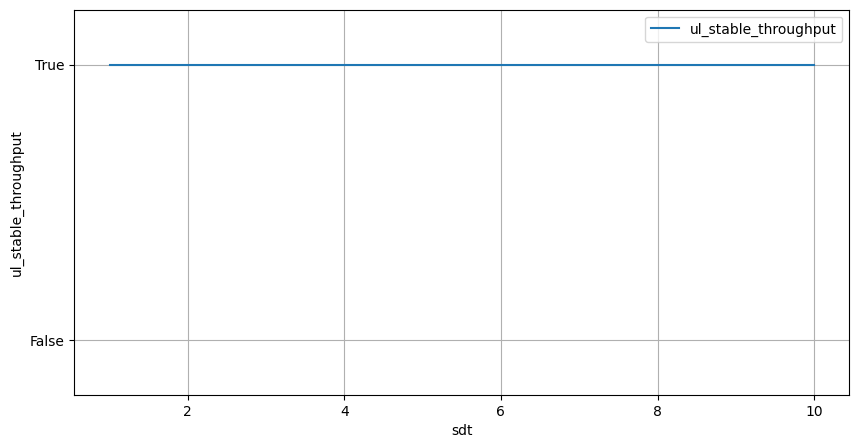

<Figure size 640x480 with 0 Axes>

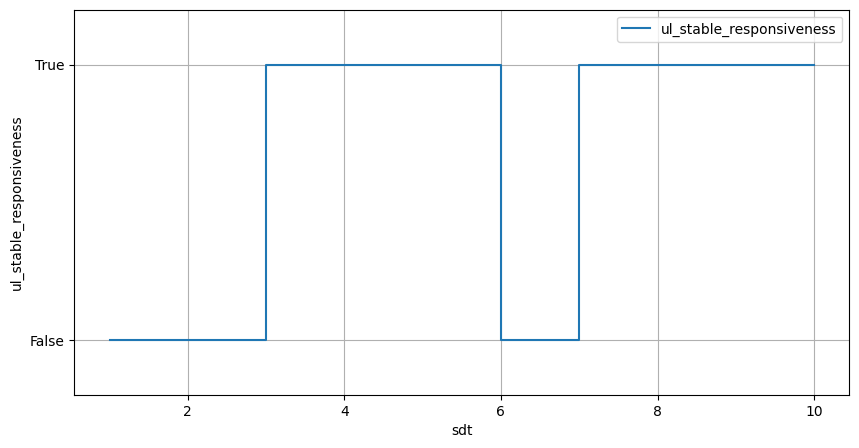

In [23]:
for out in outputs_bool:
    plt.figure()
    sdt_df.plot(x="sdt", y=out, figsize=(10, 5), grid=True, drawstyle='steps-post', xlabel="sdt", ylabel=out)

    plt.yticks([0,1], ['False', 'True'])
    plt.ylim(-0.2, 1.2)
    plt.show()

Higher sdt should reach stability faster, should test more aggressively

<h4>Maximum time for calculating RPM; test time(timeout)</h4>
default 20

<h4>RPM</h4>

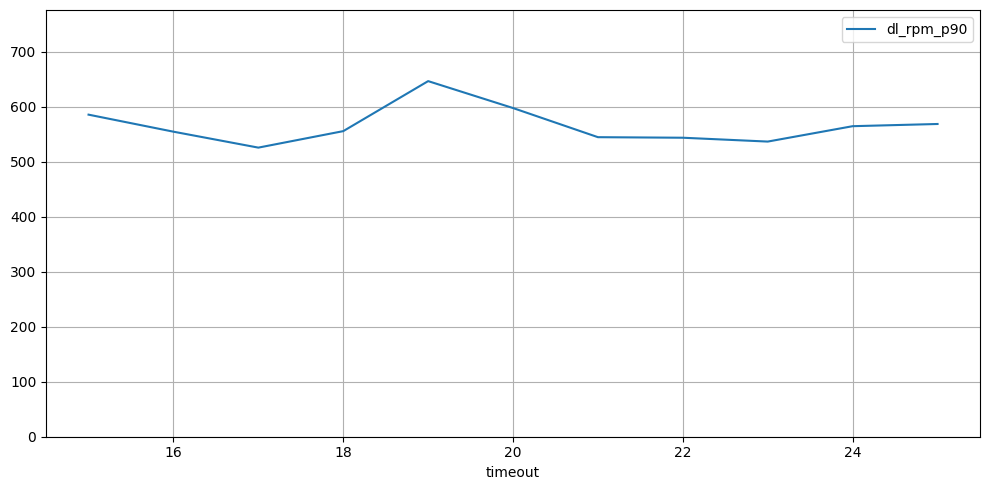

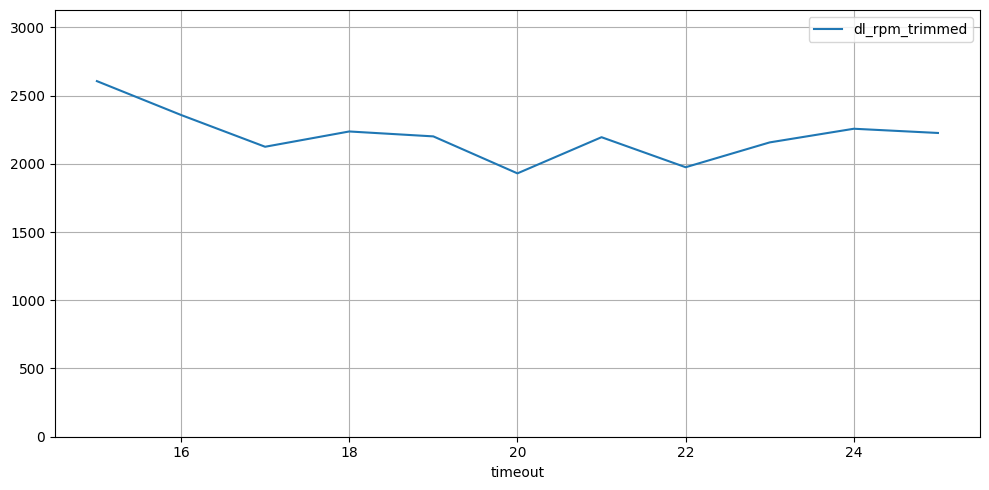

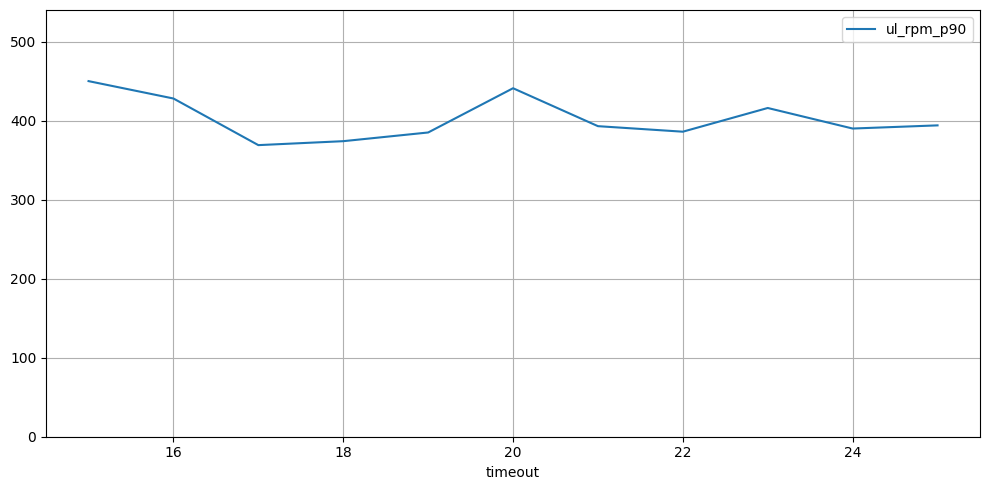

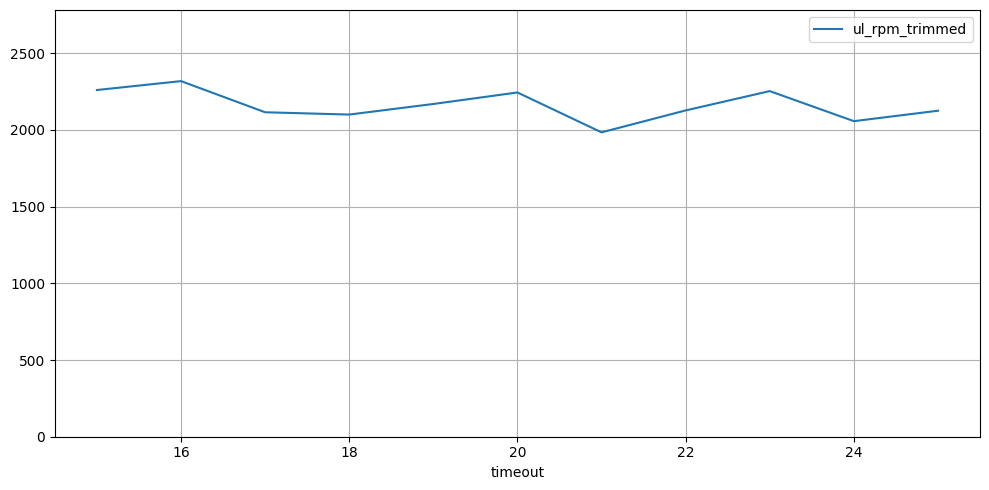

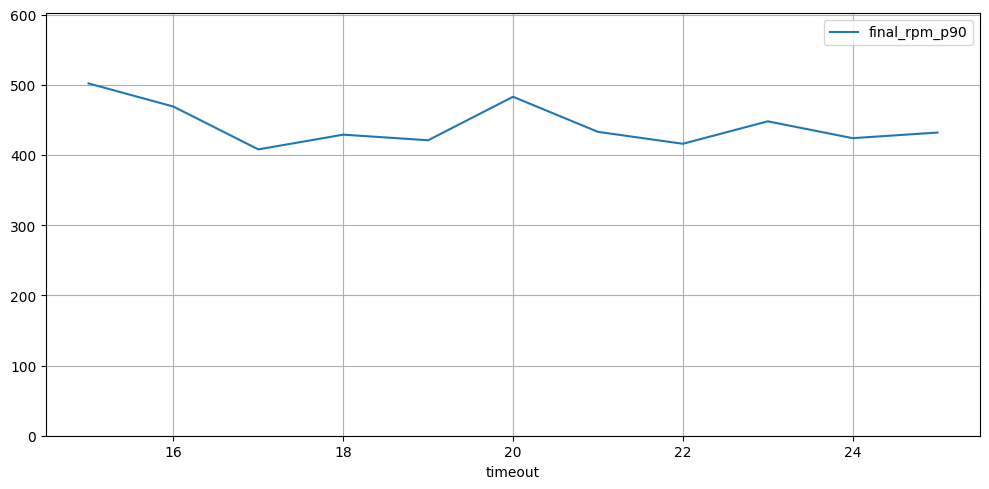

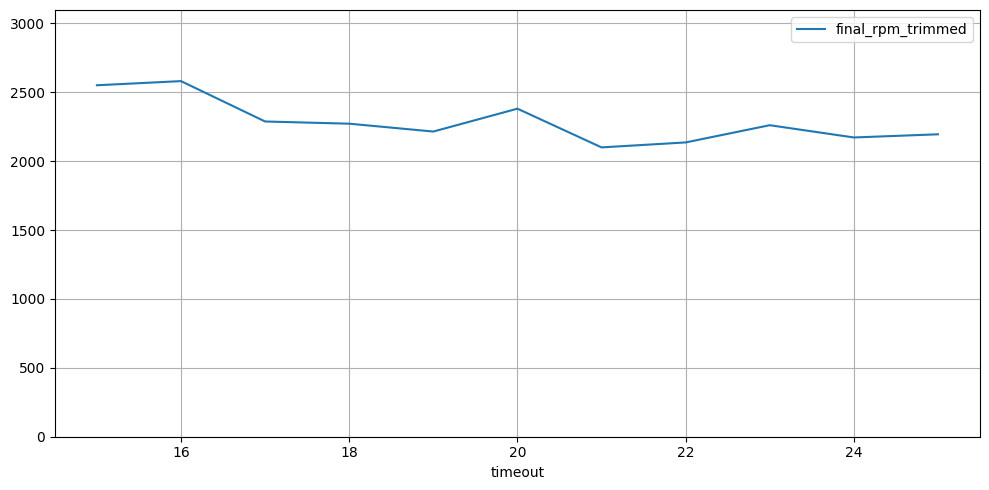

In [24]:
timeout_df = df.loc[df['exp_parameters'] == "FiberGlas timeout"]

for out in outputs_int:
    y_max = timeout_df[out].max()
    timeout_df.plot(x="timeout", y=out, figsize=(10, 5), ylim=(0, y_max * 1.2), grid=True)
    plt.tight_layout()

If the timeout is lowered, the RPM output is higher (more optimistic)

<h4>Stability</h4>

<Figure size 640x480 with 0 Axes>

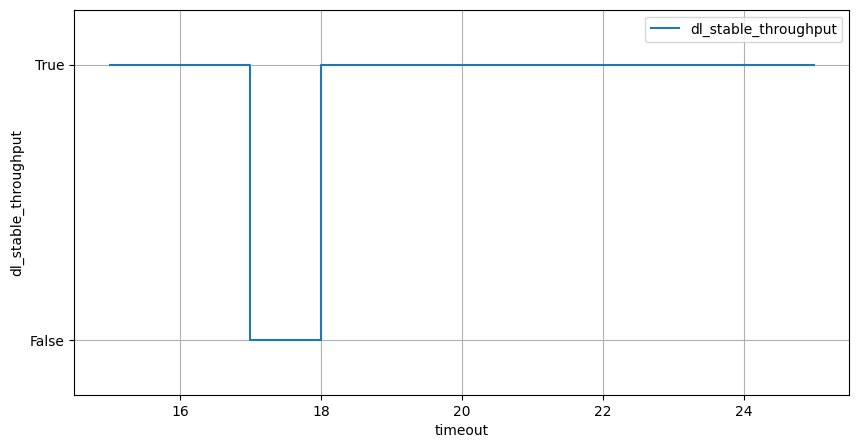

<Figure size 640x480 with 0 Axes>

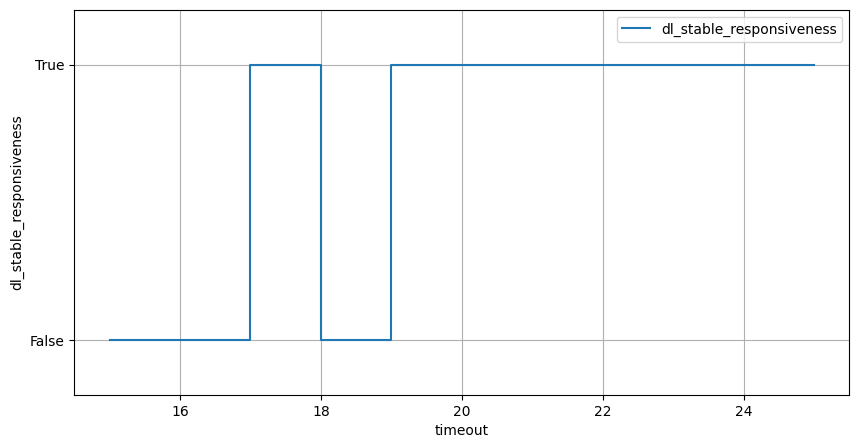

<Figure size 640x480 with 0 Axes>

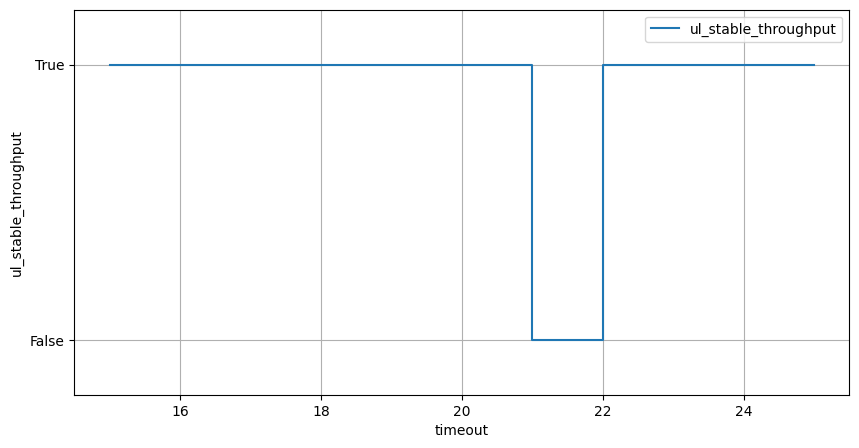

<Figure size 640x480 with 0 Axes>

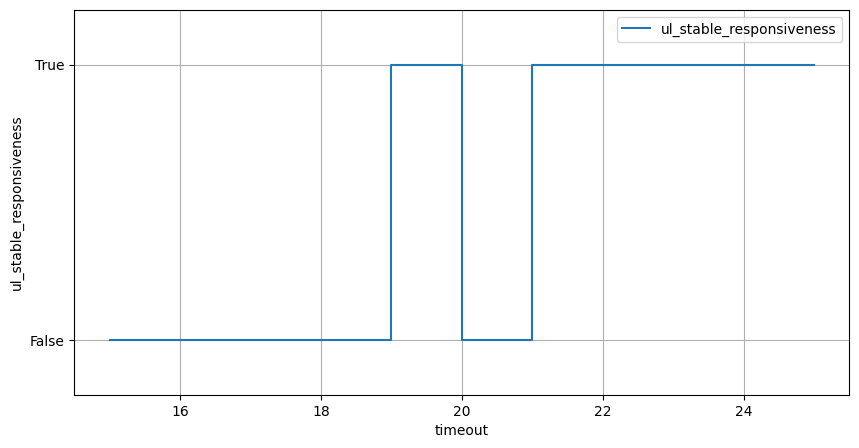

In [25]:
for out in outputs_bool:
    plt.figure()
    timeout_df.plot(x="timeout", y=out, figsize=(10, 5), grid=True, drawstyle='steps-post', xlabel="timeout", ylabel=out)

    plt.yticks([0,1], ['False', 'True'])
    plt.ylim(-0.2, 1.2)
    plt.show()

With less time, stability is hard to reach

<h4>Percentage to trim(tmp)</h4>
default 5

<h4>RPM</h4>

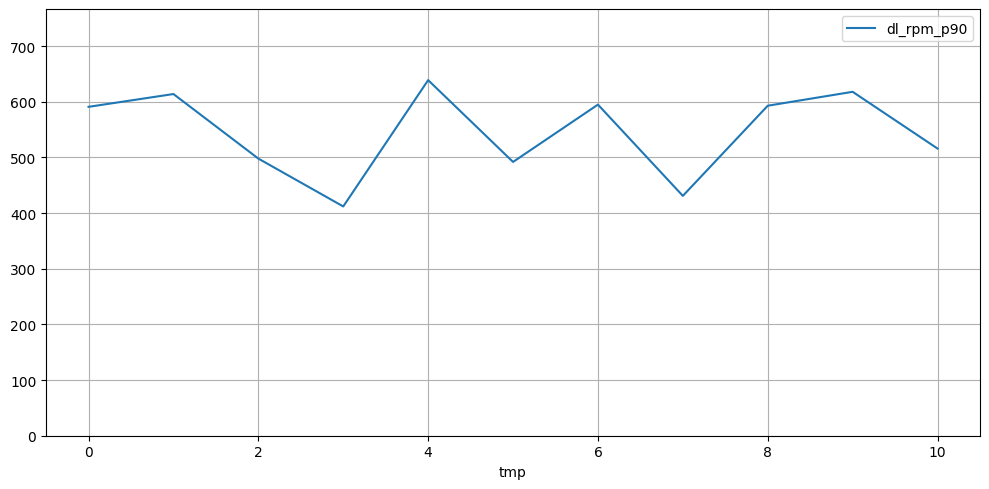

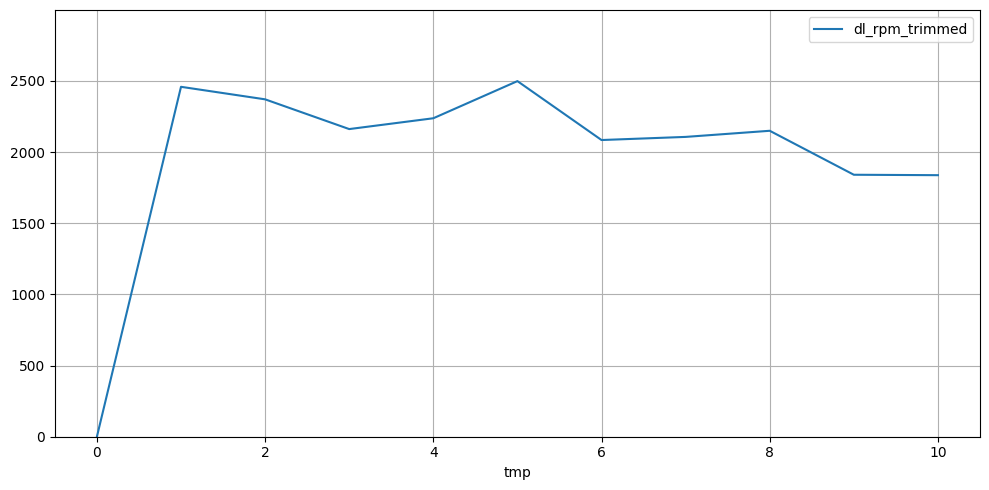

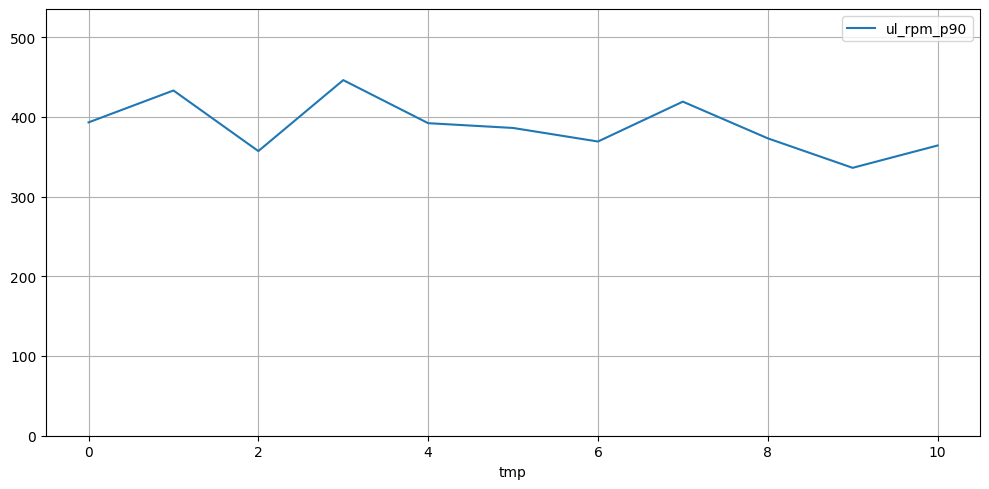

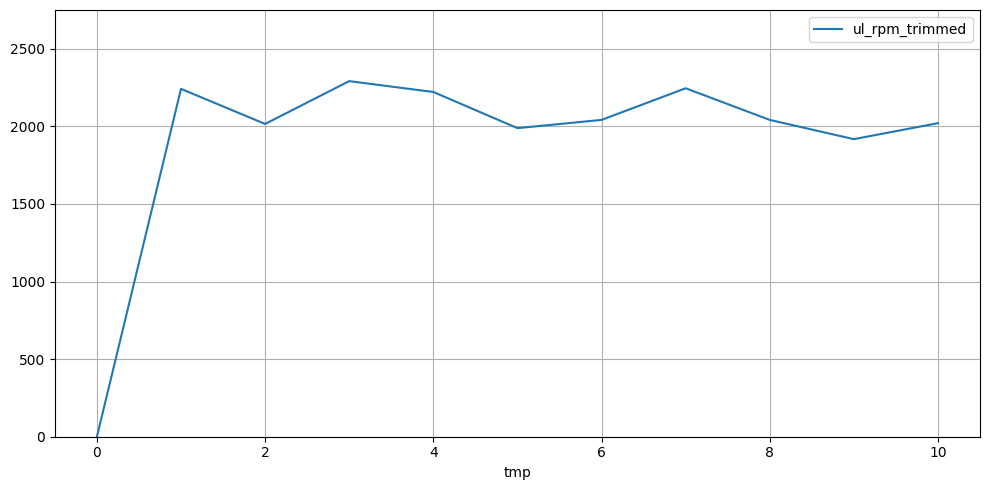

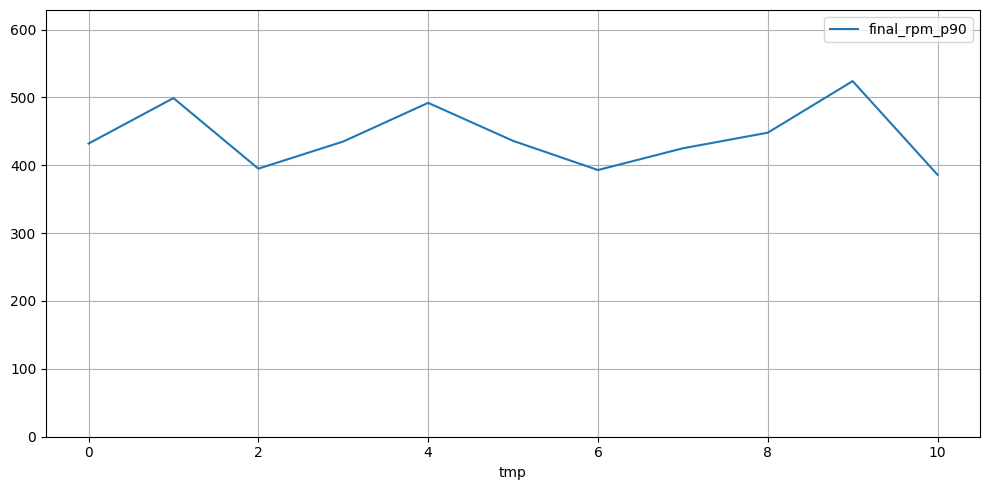

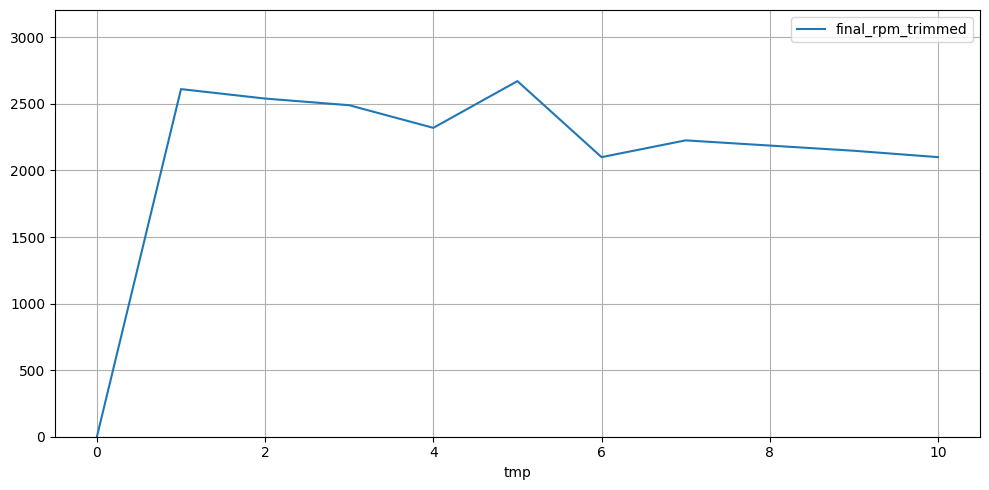

In [26]:
tmp_df = df.loc[df['exp_parameters'] == "FiberGlas tmp"]

for out in outputs_int:
    y_max = tmp_df[out].max()
    tmp_df.plot(x="tmp", y=out, figsize=(10, 5), ylim=(0, y_max * 1.2), grid=True)
    plt.tight_layout()

If tmp is 0, the trimmed RPM is NaN.

<h4>Stability</h4>

<Figure size 640x480 with 0 Axes>

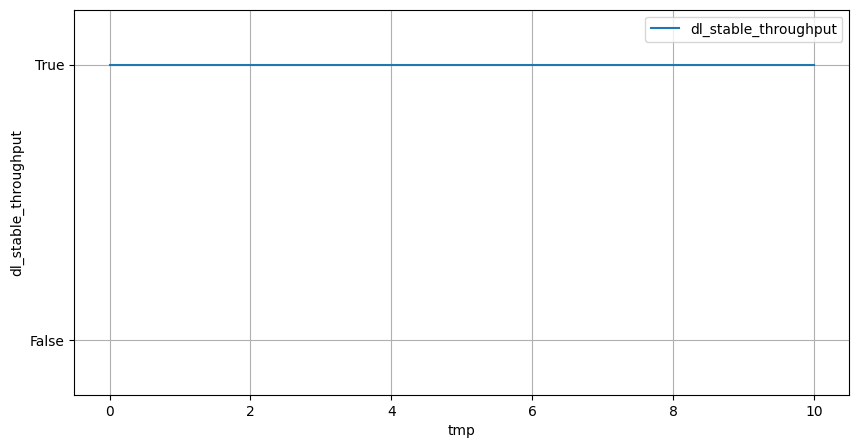

<Figure size 640x480 with 0 Axes>

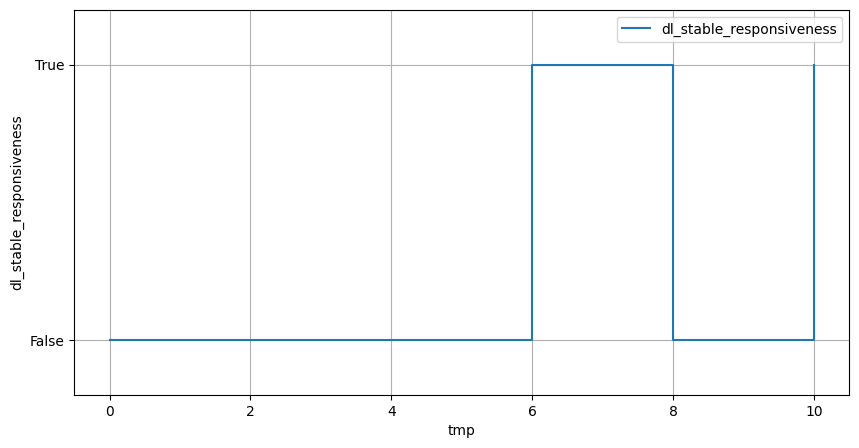

<Figure size 640x480 with 0 Axes>

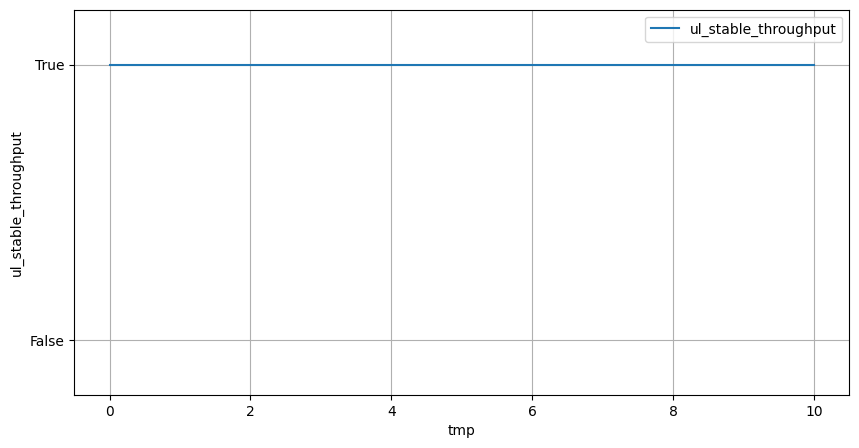

<Figure size 640x480 with 0 Axes>

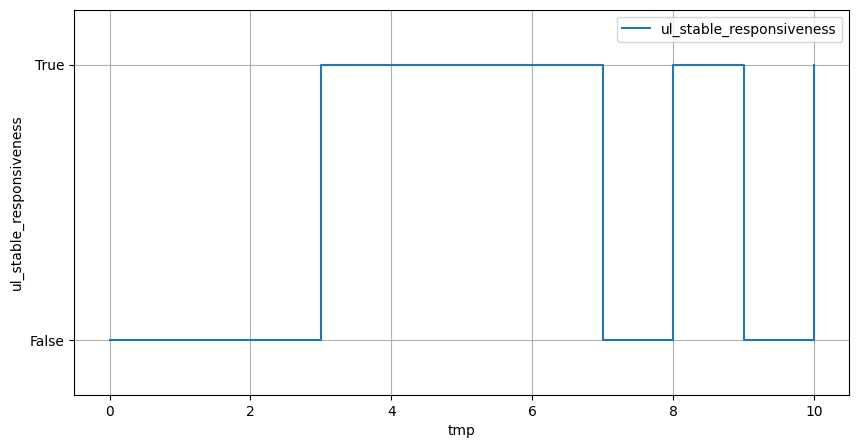

In [27]:
for out in outputs_bool:
    plt.figure()
    tmp_df.plot(x="tmp", y=out, figsize=(10, 5), grid=True, drawstyle='steps-post', xlabel="tmp", ylabel=out)

    plt.yticks([0,1], ['False', 'True'])
    plt.ylim(-0.2, 1.2)
    plt.show()

Doesnt seem to have an effect on stability